# Lipschitz curriculum

# Neural ODE no regularization: impact of longer training sequences under curriculum

In [1]:
import matplotlib.pyplot as plt 
import jax
import numpy as np 
import equinox as eqx
import os
import jax.numpy as jnp
from datasets import init_dataloaders
from solvers.runge_kutta import RK_solver_fixed, RK_tableaux
from forecasters import *
from networks import *
from utils import *

In [2]:
# test on T=40 trajectories ie test set of pendulum T=40
from datasets import * 
import os
path = 'data/lipschitz_init'
dataset_name = 'pendulum'
data_integration_method = 'RK4'
duration = 40
dt_num = 0.5
_, _, test = init_dataloaders(dataset_name, data_integration_method, os.path.join(path, dataset_name+str(duration)), dt_num=dt_num, duration=duration)

In [3]:
p_min,p_max = -2.15, 2.15
q_min, q_max = -8.03, 7.94
# get Lipschitz constant on test states 
def jacobian(model, x):
    return jax.jit(jax.jacfwd(model))(x)

def jacobian_max(models):
    jacobians_max_aug = []
    for model in models:
        q = np.linspace(-q_min, q_max, 15)
        p = np.linspace(-p_min, p_max, 15)
        Q, P = np.meshgrid(q, p)
        jac_norm_aug = []
        for y0 in zip(Q.ravel(), P.ravel()):
            y0 = np.array(y0)
            jac_norm_aug.append(np.linalg.norm(jacobian(model.model_aug, y0)))
        jacobians_max_aug.append(np.max(jac_norm_aug))
    return jacobians_max_aug

def compute_jacobian_list(model):
    jac_norm_aug = []
    q = np.linspace(-q_min, q_max, 15)
    p = np.linspace(-p_min, p_max, 15)
    Q, P = np.meshgrid(q, p)
    for y0 in zip(Q.ravel(), P.ravel()):
        y0 = np.array(y0)
        jac_norm_aug.append(np.linalg.norm(jacobian(model.model_aug, y0)))
    return jac_norm_aug

def F(y):
    return np.array([y[1], -((2*np.pi/12)**2) * np.sin(y[0]) - 0.2*y[1]])
def offline_mean(models):
    offline_means = []
    for model in models:
        q = np.linspace(-q_min, q_max, 15)
        p = np.linspace(-p_min, p_max, 15)
        Q, P = np.meshgrid(q, p)
        off_mean = []
        for y0 in zip(Q.ravel(), P.ravel()):
            y0 = np.array(y0)
            off_mean.append(np.abs(F(y0)-model.derivative_estimator(y0,0)).mean())
        offline_means.append(np.mean(off_mean))
    return offline_means

def offline_mean_test(models):
    offline_means = []
    for model in models:
        y_list = []
        for i,data in enumerate(test):
            states = jnp.array(data['states'])
            for j in range(states.shape[2]):
                y_list.append(states[0,:,j])
            if i == 24:
                break
        y_list = np.array(y_list)
        print(y_list.shape, y_list[0].shape)
        offline_mean = []
        for y0 in y_list:
            y0 = np.array(y0)
            offline_mean.append(np.abs(F(y0)-model.derivative_estimator(y0,0)).mean())
        offline_means.append(np.mean(offline_mean))
    return offline_means

def offline_max_test(models):
    offline_means = []
    for model in models:
        y_list = []
        for i,data in enumerate(test):
            states = jnp.array(data['states'])
            for j in range(states.shape[2]):
                y_list.append(states[0,:,j])
        y_list = np.array(y_list)
        print(y_list.shape, y_list[0].shape)
        offline_mean = []
        for y0 in y_list:
            y0 = np.array(y0)
            offline_mean.append(np.abs(F(y0,0)-model.derivative_estimator(y0,0)).max())
        offline_means.append(np.max(offline_mean))
    return offline_means

def jacobian_max_test(models):
    jacobians_max_aug = []
    for model in models:
        y_list = []
        for i,data in enumerate(test):
            states = jnp.array(data['states'])
            for j in range(states.shape[2]):
                y_list.append(states[0,:,j])
            if i == 24:
                break
        y_list = np.array(y_list)
        print(y_list.shape, y_list[0].shape)
        jac_norm_aug = []
        for y0 in y_list:
            y0 = np.array(y0)
            jac_norm_aug.append(np.linalg.norm(jacobian(model.model_aug, y0)))
        jacobians_max_aug.append(np.max(jac_norm_aug))
    return jacobians_max_aug

In [4]:
def compute_jacobian_test(model):
    y_list = []
    for i,data in enumerate(test):
        states = jnp.array(data['states'])
        for j in range(states.shape[2]):
            y_list.append(states[0,:,j])
        if i == 24:
            break
    y_list = np.array(y_list)
    print(y_list.shape, y_list[0].shape)
    jac_norm_aug = []
    for y0 in y_list:
        y0 = np.array(y0)
        jac_norm_aug.append(np.linalg.norm(jacobian(model.model_aug, y0)))
    return jac_norm_aug

### Load models

In [5]:
def load_pendulum(model_name,exp_name, data_path, model_phy_option, model_aug_option, dataset_name, integration_method, data_integration_method="RK4", dt_num=0.5, duration=20):
    # load test data 
    _, _, test =init_dataloaders(dataset_name, data_integration_method, os.path.join(data_path, dataset_name+str(duration)), dt_num=dt_num, duration=duration)

    # load model
    model_path = os.path.join(data_path, f"{exp_name}/{model_name}")
    print(model_path)
    with open(os.path.join(data_path, f'{exp_name}/hyperparameters.json'), 'r') as f:
        hyperparameters_dict = json.load(f)
    min_op = hyperparameters_dict['min_op']
    dt = hyperparameters_dict["dt"]
    dt_factor = int(dt/test.dataset.dt)
    print(dt, dt_factor)
    if dataset_name == 'pendulum':
        if model_phy_option == 'incomplete':
            model_phy = PendulumParamPDE(is_damped=False)
        elif model_phy_option == 'complete':
            model_phy = PendulumParamPDE(is_damped=True)
        elif model_phy_option == 'true':
            model_phy = PendulumParamPDE(is_damped=True, params=test.dataset.params)
        elif model_phy_option == 'none':
            model_phy = PendulumParamPDE(is_damped=False) # mock model for eqx compatibility
        elif model_phy_option == 'none_Fa':
            model_phy = PendulumParamPDE(is_damped=False) # mock model for eqx compatibility
        elif model_phy_option == 'incomplete_no_Fa':
            model_phy = PendulumParamPDE(is_damped=False)
        elif model_phy_option == 'none_Fa_prime':
            model_phy = PendulumParamPDE(is_damped=False)
        elif model_phy_option == 'incomplete_Fa_prime':
            model_phy = PendulumParamPDE(is_damped=False)
    
        with open(model_path, "rb") as f:
            hyperparams = json.loads(f.readline().decode())
            mkey = jax.random.PRNGKey(0)
            model_aug = MLP(key=mkey, state_c=2, hidden=200)
            net = Forecaster(
                model_phy=model_phy,
                model_aug=model_aug,
                is_augmented=model_aug_option,
                is_phy=model_phy_option,
                dt=dt,
                num_steps=int(test.dataset.num_steps/dt_factor),
                integration_method=integration_method, # error scheme exp
            )
            model = eqx.tree_deserialise_leaves(f, net)
    return model
    

In [6]:
# /Users/mayajanvier/jax-phynity/data/lipschitz_curriculum/none_aug_5_1_9823b25a/model_6.339e-04.eqx
model_name = 'model_6.339e-04.eqx'
exp_name = 'none_aug_5_1_9823b25a'
data_path = 'data/lipschitz_curriculum'
model_phy_option = 'none'
model_aug_option = True
dataset_name = 'pendulum'
integration_method = 'RK4'
duration = 5
dt_num = 0.5
aug_none5 = load_pendulum(model_name,exp_name, data_path, model_phy_option, model_aug_option, dataset_name, integration_method, dt_num=dt_num, duration=duration)


data/lipschitz_curriculum/none_aug_5_1_9823b25a/model_6.339e-04.eqx
0.5 1


In [7]:
# /Users/mayajanvier/jax-phynity/data/lipschitz_curriculum/none_aug_10_5_atx793p0/model_3.829e-03.eqx
model_name = 'model_3.829e-03.eqx'
exp_name = 'none_aug_10_5_atx793p0'
data_path = 'data/lipschitz_curriculum'
model_phy_option = 'none'
model_aug_option = True
dataset_name = 'pendulum'
integration_method = 'RK4'
duration = 10
dt_num = 0.5
aug_none10 = load_pendulum(model_name,exp_name, data_path, model_phy_option, model_aug_option, dataset_name, integration_method, dt_num=dt_num, duration=duration)


data/lipschitz_curriculum/none_aug_10_5_atx793p0/model_3.829e-03.eqx
0.5 1


In [8]:
# /Users/mayajanvier/jax-phynity/data/lipschitz_curriculum/none_aug_20_9_zbgnkgq4/model_6.752e-03.eqx
model_name = 'model_6.752e-03.eqx'
exp_name = 'none_aug_20_9_zbgnkgq4'
data_path = 'data/lipschitz_curriculum'
model_phy_option = 'none'
model_aug_option = True
dataset_name = 'pendulum'
integration_method = 'RK4'
duration = 20
dt_num = 0.5
aug_none20 = load_pendulum(model_name,exp_name, data_path, model_phy_option, model_aug_option, dataset_name, integration_method, dt_num=dt_num, duration=duration)

data/lipschitz_curriculum/none_aug_20_9_zbgnkgq4/model_6.752e-03.eqx
0.5 1


In [9]:
# /Users/mayajanvier/jax-phynity/data/lipschitz_curriculum/none_aug_40_14_ydq9q5k5/model_2.862e-03.eqx
model_name = 'model_2.862e-03.eqx'
exp_name = 'none_aug_40_14_ydq9q5k5'
data_path = 'data/lipschitz_curriculum'
model_phy_option = 'none'
model_aug_option = True
dataset_name = 'pendulum'
integration_method = 'RK4'
duration = 40
dt_num = 0.5
aug_none40 = load_pendulum(model_name,exp_name, data_path, model_phy_option, model_aug_option, dataset_name, integration_method, dt_num=dt_num, duration=duration)

data/lipschitz_curriculum/none_aug_40_14_ydq9q5k5/model_2.862e-03.eqx
0.5 1


In [10]:
# /Users/mayajanvier/jax-phynity/data/lipschitz_curriculum/none_aug_15_18_4xaco8ba/model_1.257e-02.eqx
model_name = 'model_1.257e-02.eqx'
exp_name = 'none_aug_15_18_4xaco8ba'
data_path = 'data/lipschitz_curriculum'
model_phy_option = 'none'
model_aug_option = True
dataset_name = 'pendulum'
integration_method = 'RK4'
duration = 15
dt_num = 0.5
aug_none15 = load_pendulum(model_name,exp_name, data_path, model_phy_option, model_aug_option, dataset_name, integration_method, dt_num=dt_num, duration=duration)

data/lipschitz_curriculum/none_aug_15_18_4xaco8ba/model_1.257e-02.eqx
0.5 1


In [11]:
# /Users/mayajanvier/jax-phynity/data/lipschitz_curriculum/none_aug_25_22_egopf2x9/model_8.102e-03.eqx
model_name = 'model_8.102e-03.eqx'
exp_name = 'none_aug_25_22_egopf2x9'
data_path = 'data/lipschitz_curriculum'
model_phy_option = 'none'
model_aug_option = True
dataset_name = 'pendulum'
integration_method = 'RK4'
duration = 25
dt_num = 0.5
aug_none25 = load_pendulum(model_name,exp_name, data_path, model_phy_option, model_aug_option, dataset_name, integration_method, dt_num=dt_num, duration=duration)

data/lipschitz_curriculum/none_aug_25_22_egopf2x9/model_8.102e-03.eqx
0.5 1


In [12]:
# /Users/mayajanvier/jax-phynity/data/lipschitz_curriculum/none_aug_30_26_d6w9bgr7/model_3.157e-03.eqx
model_name = 'model_3.157e-03.eqx'
exp_name = 'none_aug_30_26_d6w9bgr7'
data_path = 'data/lipschitz_curriculum'
model_phy_option = 'none'
model_aug_option = True
dataset_name = 'pendulum'
integration_method = 'RK4'
duration = 30
dt_num = 0.5
aug_none30 = load_pendulum(model_name,exp_name, data_path, model_phy_option, model_aug_option, dataset_name, integration_method, dt_num=dt_num, duration=duration)

data/lipschitz_curriculum/none_aug_30_26_d6w9bgr7/model_3.157e-03.eqx
0.5 1


In [13]:
# /Users/mayajanvier/jax-phynity/data/lipschitz_curriculum/none_aug_35_30_cqsxyvkz/model_1.410e-03.eqx
model_name = 'model_1.410e-03.eqx'
exp_name = 'none_aug_35_30_cqsxyvkz'
data_path = 'data/lipschitz_curriculum'
model_phy_option = 'none'
model_aug_option = True
dataset_name = 'pendulum'
integration_method = 'RK4'
duration = 35
dt_num = 0.5
aug_none35 = load_pendulum(model_name,exp_name, data_path, model_phy_option, model_aug_option, dataset_name, integration_method, dt_num=dt_num, duration=duration)

data/lipschitz_curriculum/none_aug_35_30_cqsxyvkz/model_1.410e-03.eqx
0.5 1


In [14]:
# /Users/mayajanvier/jax-phynity/data/lipschitz_curriculum/none_aug_50_40_ftfbayku/model_1.702e-03.eqx
model_name = 'model_1.702e-03.eqx'
exp_name = 'none_aug_50_40_ftfbayku'
data_path = 'data/lipschitz_curriculum'
model_phy_option = 'none'
model_aug_option = True
dataset_name = 'pendulum'
integration_method = 'RK4'
duration = 50
dt_num = 0.5
aug_none50 = load_pendulum(model_name,exp_name, data_path, model_phy_option, model_aug_option, dataset_name, integration_method, dt_num=dt_num, duration=duration)

data/lipschitz_curriculum/none_aug_50_40_ftfbayku/model_1.702e-03.eqx
0.5 1


### Max jacobian

In [8]:
# compute lipschitz constants

models_ode = [aug_none5, aug_none10]
jacobians_max_aug = jacobian_max(models_ode)
jacobian_max_test = jacobian_max_test(models_ode)


(2025, 2) (2,)
(2025, 2) (2,)


In [79]:
models_ode = [aug_none5, aug_none10, aug_none15, aug_none20, aug_none25, aug_none30, aug_none35, aug_none40]
jacobians_max_aug = jacobian_max(models_ode)

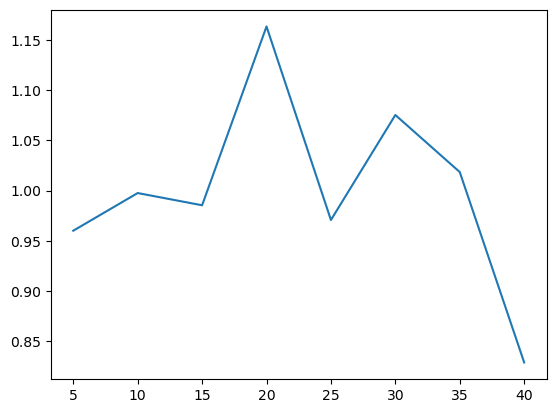

In [80]:
plt.plot([5,10,15,20,25,30,35,40], jacobians_max_aug)

In [13]:
lips = jacobian_max_test
lips

[1.3053851, 1.3345325]

In [15]:
jac_max20 = jacobian_max_test([aug_none20])

(2025, 2) (2,)


In [30]:
durations = [5, 10, 20, 40]
jac_max40 = jacobian_max_test([aug_none40])

(2025, 2) (2,)


In [33]:
# compute MSE over test set
import pandas as pd 
def F(y,t):
    return jnp.array([y[1], -((2*jnp.pi/12)**2) * jnp.sin(y[0]) - 0.2 * y[1]])

def compute_trajectories(F_model, y0_list, dt_truth=0.05, dt_factor=1, t1=20):
    y_true_list = []
    y_pred_list = []
    dico = {}
    dt = dt_factor * dt_truth
    for i, y0 in enumerate(y0_list):
        y_true = RK_solver_fixed(F,y0,dt_truth, int((t1 - t0) / dt_truth),RK_tableaux["RK4"])[0][:,::dt_factor] #y(T)
        y_pred = RK_solver_fixed(F_model,y0,dt, int((t1 - t0) / dt),RK_tableaux["RK4"])[0] #y(T)
        y_true_list.append(y_true)
        y_pred_list.append(y_pred)
        dico[i] = {
            "y0": y0,
            "y_true": y_true,
            "y_pred" :y_pred,
            }
    return pd.DataFrame(dico).T

def load_results(results_pth):
    results = pd.read_json(results_pth).T
    exp_name = results_pth.split("/")[-2]
    val_loss = float(results_pth.split("_")[-1][:-6])

    # add initial conditions to dataframe
    results["q0"] = results["states"].apply(lambda x: x[0][0])
    results["p0"] = results["states"].apply(lambda x: x[1][0])
    return results, exp_name, val_loss

# get initial states
none_path = "/Users/mayajanvier/jax-phynity/data/lipschitz_init/none_aug_40_7_g5si31tr/model_5.308e-01.json"
none_results, none_exp_name, none_val_loss = load_results(none_path)
y0s = []
for i in range(len(none_results)):
    y0s.append(np.array(none_results['states'][i])[:,0])
y0s = np.array(y0s)

def compute_metrics(data, compute_phy=True, eps=0.01):
    #data = compute_trajectories(F_model, y0_list, dt=0.5, t1=400)
    data["L1"] = data.apply(lambda x: np.mean(np.abs(x["y_true"] - x["y_pred"])), axis=1)
    data["L2"] = data.apply(lambda x: np.mean(np.array((x["y_true"] - x["y_pred"])**2)), axis=1)
    data["L2_50s"] = data.apply(lambda x: np.mean(np.array((x["y_true"][:,:101] - x["y_pred"][:,:101])**2)), axis=1)
    data["stationary_index"] = data.apply(lambda x: np.where((np.abs(np.array(x["y_true"][1,::-1])).cumsum()[::-1] > eps)==False)[0][0], axis=1)
    data["L2_dynamic"] = data.apply(lambda x: np.mean(np.array((x["y_true"][:,:x["stationary_index"]] - x["y_pred"][:,:x["stationary_index"]])**2)), axis=1)
    data["p_inf_true"] = data.apply(lambda x: x["y_true"][1,-1:], axis=1)
    data["p_inf_pred"] = data.apply(lambda x: x["y_pred"][1,-1:], axis=1)
    data["q_inf_true"] = data.apply(lambda x: x["y_true"][0,-1:], axis=1)
    data["q_inf_pred"] = data.apply(lambda x: x["y_pred"][0,-1:], axis=1)
    data["p_inf_pred_mean"] = data.apply(lambda x: np.mean(np.abs(x["y_pred"][1,-20:])), axis=1)
    data["p_inf_true_mean"] = data.apply(lambda x: np.mean(np.abs(x["y_true"][1,-20:])), axis=1)
    data["q_inf_pred_mean"] = data.apply(lambda x: np.mean(x["y_pred"][0,-20:]), axis=1)
    data["q_inf_true_mean"] = data.apply(lambda x: np.mean(x["y_true"][0,-20:]), axis=1)

    if compute_phy:
        # "max" is where p changes sign for the first time
        p_lim_true = data.apply(lambda x: np.where(np.sign(x["y_true"][1,:-1]) - np.sign(x["y_true"][1,1:]) != 0)[0][0], axis=1)
        p_lim_pred = data.apply(lambda x: np.where(np.sign(x["y_pred"][1,:-1]) - np.sign(x["y_pred"][1,1:]) != 0)[0][0], axis=1)
        data["p_lim_true"] = p_lim_true
        data["p_lim_pred"] = p_lim_pred
        #print(p_lim_true.max(), p_lim_pred.max())
        data["q_max_pred"] = data.apply(lambda x: x["y_pred"][0,x["p_lim_pred"]], axis=1)
        data["q_max_true"] = data.apply(lambda x: x["y_true"][0,x["p_lim_true"]], axis=1)
        #data["q_max_pred"] = data.apply(lambda x: np.max(np.abs(x["y_pred"][0,1:])), axis=1)
        #data["q_max_true"] = data.apply(lambda x: np.max(np.abs(x["y_true"][0,1:])), axis=1)
        data["q_inf_modulo2pi_pred"] = data.apply(lambda x: min(np.abs(x["q_inf_pred"]%(2*np.pi)), np.abs(x["q_inf_pred"]%(-2*np.pi))), axis=1)
        data["q_inf_modulo2pi_true"] = data.apply(lambda x: min(np.abs(x["q_inf_true"]%(2*np.pi)), np.abs(x["q_inf_true"]%(-2*np.pi))), axis=1)
        data["pred_isphysical"] = np.abs(data["q_inf_pred"]-data["q_max_pred"]) < np.pi
        data["true_isphysical"] = np.abs(data["q_inf_true"]-data["q_max_true"]) < np.pi
    return data

In [16]:
F_aug_none5 = aug_none5.derivative_estimator
F_aug_none10 = aug_none10.derivative_estimator
F_aug_none15 = aug_none15.derivative_estimator
F_aug_none20 = aug_none20.derivative_estimator
F_aug_none25 = aug_none25.derivative_estimator
F_aug_none30 = aug_none30.derivative_estimator
F_aug_none35 = aug_none35.derivative_estimator
F_aug_none40 = aug_none40.derivative_estimator
F_aug_none50 = aug_none50.derivative_estimator

In [18]:
t0=0
data_aug_none50 = compute_trajectories(F_aug_none50, y0s, dt_truth=0.5, dt_factor=1, t1=200)

In [19]:
data_aug_none40 = compute_trajectories(F_aug_none40, y0s, dt_truth=0.5, dt_factor=1, t1=200)

In [20]:
data_aug_none20 = compute_trajectories(F_aug_none20, y0s, dt_truth=0.5, dt_factor=1, t1=200)


In [21]:
data_aug_none30 = compute_trajectories(F_aug_none30, y0s, dt_truth=0.5, dt_factor=1, t1=200)


In [28]:
data_aug_none25 = compute_trajectories(F_aug_none25, y0s, dt_truth=0.5, dt_factor=1, t1=200)


In [29]:
data_aug_none35 = compute_trajectories(F_aug_none35, y0s, dt_truth=0.5, dt_factor=1, t1=200)

In [84]:
data_aug_none15 = compute_trajectories(F_aug_none15, y0s, dt_truth=0.5, dt_factor=1, t1=200)
data_aug_none20 = compute_trajectories(F_aug_none20, y0s, dt_truth=0.5, dt_factor=1, t1=200)
data_aug_none25 = compute_trajectories(F_aug_none25, y0s, dt_truth=0.5, dt_factor=1, t1=200)
data_aug_none30 = compute_trajectories(F_aug_none30, y0s, dt_truth=0.5, dt_factor=1, t1=200)
data_aug_none35 = compute_trajectories(F_aug_none35, y0s, dt_truth=0.5, dt_factor=1, t1=200)

In [23]:
t0=0
data_aug_none5 = compute_trajectories(F_aug_none5, y0s, dt_truth=0.5, t1=200)
data_aug_none10 = compute_trajectories(F_aug_none10, y0s, dt_truth=0.5, t1=200)
data_aug_none20 = compute_trajectories(F_aug_none20, y0s, dt_truth=0.5, t1=200)

In [34]:
#metrics_aug_none10 = compute_metrics(data_aug_none10, compute_phy=False)
metrics_aug_none20 = compute_metrics(data_aug_none20, compute_phy=False)
metrics_aug_none30 = compute_metrics(data_aug_none30, compute_phy=False)
metrics_aug_none40 = compute_metrics(data_aug_none40, compute_phy=False)

In [35]:
#metrics_aug_none5 = compute_metrics(data_aug_none5, compute_phy=False)
#metrics_aug_none15 = compute_metrics(data_aug_none15, compute_phy=False)
metrics_aug_none25 = compute_metrics(data_aug_none25, compute_phy=False)
metrics_aug_none35 = compute_metrics(data_aug_none35, compute_phy=False)


In [37]:
metrics_aug_none50 = compute_metrics(data_aug_none50, compute_phy=False)

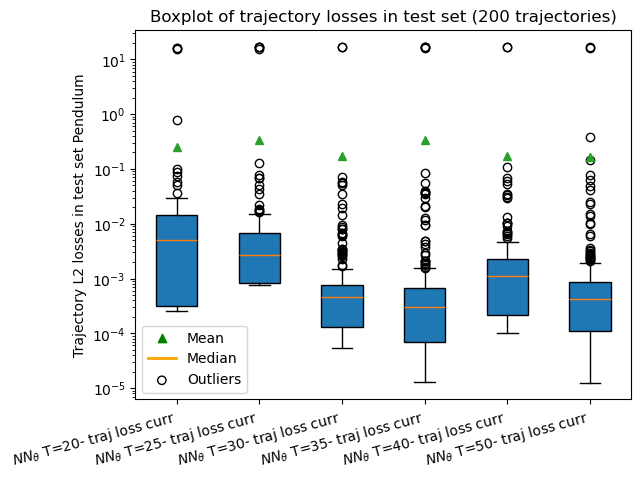

In [39]:
# boxplot meilleur
metric_name="L2_dynamic"
losses_traj = [
    #metrics_aug_none10["L2_dynamic"],
    #metrics_aug_none15["L2_dynamic"],
    metrics_aug_none20[metric_name],
    metrics_aug_none25[metric_name],
    metrics_aug_none30[metric_name],
    metrics_aug_none35[metric_name],
    metrics_aug_none40[metric_name],
    metrics_aug_none50[metric_name],
]
labels = [
          #r'$NN_{\theta}$ T=10- traj loss curr',
          #r'$NN_{\theta}$ T=15- traj loss curr',
          r'$NN_{\theta}$ T=20- traj loss curr',
          r'$NN_{\theta}$ T=25- traj loss curr',
          r'$NN_{\theta}$ T=30- traj loss curr',
          r'$NN_{\theta}$ T=35- traj loss curr',
          r'$NN_{\theta}$ T=40- traj loss curr',
          r'$NN_{\theta}$ T=50- traj loss curr',]
#colors = ['peachpuff', 'orange', 'tomato']

fig, ax = plt.subplots()
ax.set_ylabel('Trajectory L2 losses in test set Pendulum')
#ax.set_ylim(0.005,0.5)
ax.set_yscale('log')


# orientation en biais
bplot = ax.boxplot(
    losses_traj,
    patch_artist=True,
    showmeans=True
)

ax.set_xticks([1, 2, 3, 4,5,6])
ax.set_xticklabels(labels, rotation=15, ha='right')
# dummy legend
mean_legend = plt.scatter([], [], color='green', marker='^', label='Mean')
median_legend = plt.Line2D([0], [0], color='orange', linewidth=2, label='Median')
outlier_legend = plt.scatter([],[], marker= 'o',edgecolors='black', facecolors='none', label='Outliers')

ax.legend(handles=[mean_legend, median_legend, outlier_legend], loc='lower left')
# fill with colors
# for patch, color in zip(bplot['boxes'], colors):
#     patch.set_facecolor(color)
plt.title(f"Boxplot of trajectory losses in test set (200 trajectories)")#), T={mean_T}s)")
plt.show()

In [77]:
L_true = np.sqrt(1+(2*np.pi/12)**4 + 0.2**2)

Text(0, 0.5, 'Estimated Lipschitz constant')

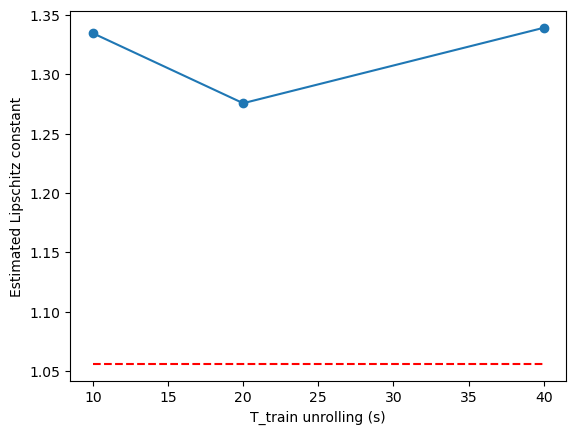

In [116]:
plt.plot(durations[1:],lips[1:]+jac_max20+jac_max40, label='Lipschitz constant on test set (25 traj)', marker='o')
plt.hlines(L_true, 10,40, linestyles='dashed', color='red', label='True Lipschitz constant')
plt.xlabel('T_train unrolling (s)')
plt.ylabel('Estimated Lipschitz constant')


### Violin jacobian

In [144]:
lip_data_aug_none5 = compute_jacobian_test(aug_none5)
lip_data_aug_none5

(2025, 2) (2,)


[0.9534039,
 1.0205678,
 1.0154523,
 0.98106736,
 0.94106007,
 0.9685221,
 0.98933756,
 0.9812988,
 1.0843673,
 1.1429739,
 1.1123931,
 1.07778,
 0.9741366,
 0.9163209,
 0.8551442,
 0.78182995,
 0.7822297,
 0.82604307,
 0.88802606,
 0.91851336,
 0.95266247,
 1.0154088,
 1.004586,
 1.0020324,
 1.0087905,
 0.9814979,
 0.99566096,
 0.9117917,
 0.940596,
 0.99904805,
 0.9220604,
 0.9188139,
 0.87649417,
 0.85498524,
 0.8453533,
 0.8453533,
 0.8453533,
 0.8453533,
 0.8394516,
 0.8307747,
 0.83653957,
 0.8309185,
 0.84805304,
 0.8387115,
 0.8236471,
 0.8377246,
 0.84637135,
 0.8358809,
 0.8358809,
 0.8451205,
 0.85415477,
 0.85547876,
 0.84678787,
 0.90297633,
 0.924184,
 0.8997153,
 0.9006218,
 0.8928133,
 0.8928133,
 0.8928133,
 0.8928133,
 0.8928133,
 0.878827,
 0.878827,
 0.9022882,
 0.89504945,
 0.88068694,
 0.8555148,
 0.8639838,
 0.8566045,
 0.87069446,
 0.8612882,
 0.8612882,
 0.8612882,
 0.87069446,
 0.8898651,
 0.90297633,
 0.90297633,
 0.9169768,
 0.90340996,
 0.91058433,
 1.01226

In [147]:
lip_data_aug_none10 = compute_jacobian_test(aug_none10)
lip_data_aug_none15 = compute_jacobian_test(aug_none15)
lip_data_aug_none20 = compute_jacobian_test(aug_none20)


(2025, 2) (2,)
(2025, 2) (2,)
(2025, 2) (2,)


In [148]:
lip_data_aug_none25 = compute_jacobian_test(aug_none25)
lip_data_aug_none30 = compute_jacobian_test(aug_none30)
lip_data_aug_none35 = compute_jacobian_test(aug_none35)

(2025, 2) (2,)
(2025, 2) (2,)
(2025, 2) (2,)


In [149]:
lip_data_aug_none40 = compute_jacobian_test(aug_none40)
lip_data_aug_none50 = compute_jacobian_test(aug_none50)

(2025, 2) (2,)
(2025, 2) (2,)


In [150]:
df_curr = pd.DataFrame({
    "5s": lip_data_aug_none5,
    "10s": lip_data_aug_none10,
    "15s": lip_data_aug_none15,
    "20s": lip_data_aug_none20,
    "25s": lip_data_aug_none25,
    "30s": lip_data_aug_none30,
    "35s": lip_data_aug_none35,
    "40s": lip_data_aug_none40,
    "50s": lip_data_aug_none50})
df_curr

,5s,10s,15s,20s,25s,30s,35s,40s,50s
0,0.953404,0.930671,0.872847,0.983604,0.885524,1.046179,0.970763,0.879916,0.981543
1,1.020568,0.993246,0.956502,1.036603,0.990845,1.050852,1.025750,1.048494,1.040781
2,1.015452,1.107117,1.082422,1.200627,1.077757,1.058609,1.125282,1.270944,1.233966
3,0.981067,1.013904,0.969767,1.030092,1.186113,1.088031,1.089078,1.283921,1.261866
4,0.941060,0.994004,1.021134,0.971284,1.197210,1.001407,1.009268,1.130238,1.141661
...,...,...,...,...,...,...,...,...,...
2020,0.828119,0.876419,0.905027,1.074470,0.999360,1.023249,1.008546,0.980271,0.998600
2021,0.828119,0.876419,0.905027,1.074470,0.999360,1.023249,1.008546,0.989821,0.998600
2022,0.828119,0.876419,0.905027,1.074470,1.007290,1.025372,1.016241,1.000454,0.998600
2023,0.828119,0.876419,0.905027,1.074470,1.007290,1.034453,1.016241,1.004353,0.998600


In [725]:
save_data_traj(df_curr, "data/lipschitz_curriculum/lipschitz_curriculum_ode.csv")

Text(0, 0.5, 'Jacobian norm')

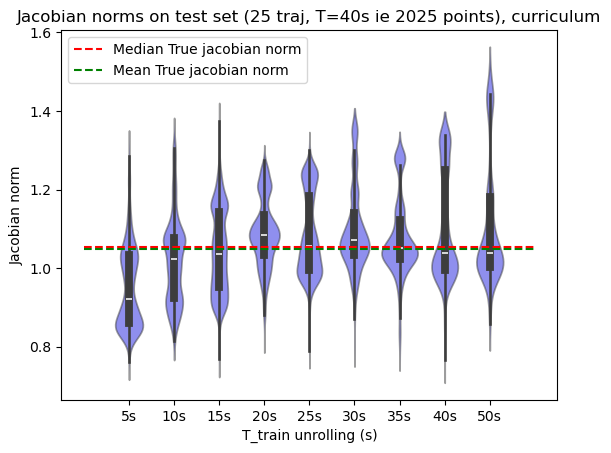

In [197]:
import seaborn as sns

sns.violinplot(df_curr, color='blue', alpha=0.5)
plt.hlines(df_true.median(), -1, 9, linestyles='dashed', color='red', label='Median True jacobian norm')
plt.hlines(df_true.mean(), -1, 9, linestyles='dashed', color='green', label='Mean True jacobian norm')
plt.legend()
plt.title('Jacobian norms on test set (25 traj, T=40s ie 2025 points), curriculum')
plt.xlabel('T_train unrolling (s)')
plt.ylabel('Jacobian norm')


Text(0, 0.5, 'Estimated Jacobian norm')

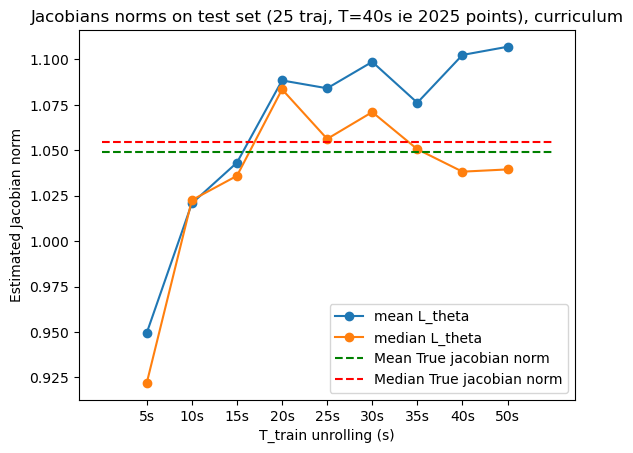

In [641]:
plt.plot(df_curr.mean(), label='mean L_theta', marker='o')
plt.plot(df_curr.median(), label='median L_theta', marker='o')
plt.hlines(df_true.mean(), -1, 9, linestyles='dashed', color='green', label='Mean True jacobian norm')
plt.hlines(df_true.median(), -1, 9, linestyles='dashed', color='red', label='Median True jacobian norm')
plt.legend()
plt.title("Jacobians norms on test set (25 traj, T=40s ie 2025 points), curriculum")
plt.xlabel('T_train unrolling (s)')
plt.ylabel('Estimated Jacobian norm')

In [651]:
diff_L_mean = (df_curr.mean()).apply(lambda x: np.abs(x- df_true.mean()))
diff_L_median = (df_curr.median()).apply(lambda x: np.abs(x- df_true.mean()))

Text(0.5, 1.0, 'on test trajectories (true)')

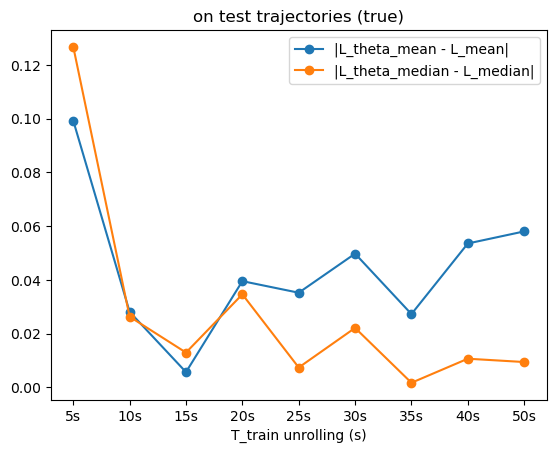

In [654]:
plt.plot(diff_L_mean, label='|L_theta_mean - L_mean|', marker='o')
plt.plot(diff_L_median, label='|L_theta_median - L_median|', marker='o')
plt.legend()
plt.xlabel('T_train unrolling (s)')
plt.title("on test trajectories (true)")

In [664]:
df_curr["true"] = df_true
df_curr

,5s,10s,15s,20s,25s,30s,35s,40s,50s,true
0,0.953404,0.930671,0.872847,0.983604,0.885524,1.046179,0.970763,0.879916,0.981543,1.035312
1,1.020568,0.993246,0.956502,1.036603,0.990845,1.050852,1.025750,1.048494,1.040781,1.020262
2,1.015452,1.107117,1.082422,1.200627,1.077757,1.058609,1.125282,1.270944,1.233966,1.038329
3,0.981067,1.013904,0.969767,1.030092,1.186113,1.088031,1.089078,1.283921,1.261866,1.054515
4,0.941060,0.994004,1.021134,0.971284,1.197210,1.001407,1.009268,1.130238,1.141661,1.052948
...,...,...,...,...,...,...,...,...,...,...
2020,0.828119,0.876419,0.905027,1.074470,0.999360,1.023249,1.008546,0.980271,0.998600,1.055995
2021,0.828119,0.876419,0.905027,1.074470,0.999360,1.023249,1.008546,0.989821,0.998600,1.056004
2022,0.828119,0.876419,0.905027,1.074470,1.007290,1.025372,1.016241,1.000454,0.998600,1.056010
2023,0.828119,0.876419,0.905027,1.074470,1.007290,1.034453,1.016241,1.004353,0.998600,1.056012


In [665]:
# avec chaque point
df_L_diff = df_curr.apply(lambda x: np.abs(x- x["true"]), axis=1)
df_L_diff

,5s,10s,15s,20s,25s,30s,35s,40s,50s,true
0,0.081908,0.104641,0.162466,0.051708,0.149788,0.010867,0.064549,0.155396,0.053769,0.0
1,0.000306,0.027016,0.063761,0.016341,0.029417,0.030590,0.005488,0.028232,0.020519,0.0
2,0.022876,0.068788,0.044093,0.162298,0.039429,0.020281,0.086954,0.232615,0.195638,0.0
3,0.073447,0.040611,0.084748,0.024422,0.131598,0.033517,0.034563,0.229407,0.207351,0.0
4,0.111888,0.058944,0.031814,0.081664,0.144262,0.051541,0.043680,0.077290,0.088713,0.0
...,...,...,...,...,...,...,...,...,...,...
2020,0.227875,0.179576,0.150968,0.018475,0.056635,0.032745,0.047449,0.075724,0.057395,0.0
2021,0.227885,0.179585,0.150978,0.018466,0.056644,0.032755,0.047458,0.066183,0.057404,0.0
2022,0.227891,0.179591,0.150983,0.018460,0.048720,0.030638,0.039769,0.055556,0.057410,0.0
2023,0.227893,0.179593,0.150985,0.018458,0.048722,0.021559,0.039771,0.051659,0.057412,0.0


Text(0.5, 1.0, 'L1 error on jacobian norms on test set (25 traj, T=40s ie 2025 points), curriculum')

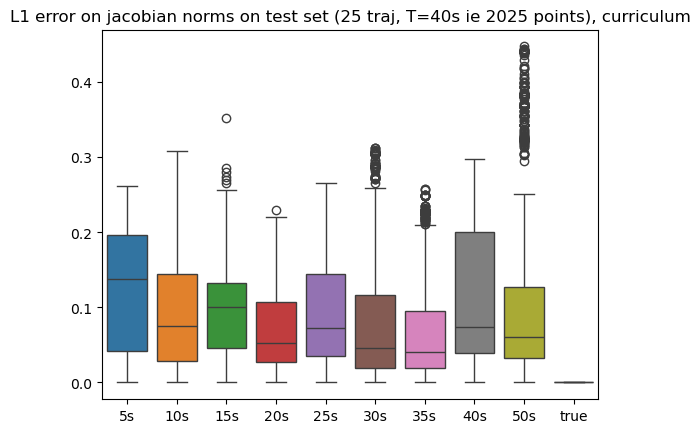

In [672]:
#sns.violinplot(df_L_diff, color='blue', alpha=0.5)
sns.boxplot(df_L_diff)
plt.title("L1 error on jacobian norms on test set (25 traj, T=40s ie 2025 points), curriculum")

In [662]:
df_L_diff

0             10s  15s  20s  25s  30s  35s  40s  50s  ...
1             10s  15s  20s  25s  30s  35s  40s  50s  ...
2             10s  15s  20s  25s  30s  35s  40s  50s  ...
3             10s  15s  20s  25s  30s  35s  40s  50s  ...
4             10s  15s  20s  25s  30s  35s  40s  50s  ...
                              ...                        
2020          10s  15s  20s  25s  30s  35s  40s  50s  ...
2021          10s  15s  20s  25s  30s  35s  40s  50s  ...
2022          10s  15s  20s  25s  30s  35s  40s  50s  ...
2023          10s  15s  20s  25s  30s  35s  40s  50s  ...
2024          10s  15s  20s  25s  30s  35s  40s  50s  ...
Length: 2025, dtype: object

### MSE curriculum

In [126]:
mean_mses = [metrics_aug_none5["L2_dynamic"].mean(), 
             metrics_aug_none10["L2_dynamic"].mean(),
             metrics_aug_none15["L2_dynamic"].mean(),
             metrics_aug_none20["L2_dynamic"].mean(),
             metrics_aug_none25["L2_dynamic"].mean(),
             metrics_aug_none30["L2_dynamic"].mean(),
             metrics_aug_none35["L2_dynamic"].mean(),
             metrics_aug_none40["L2_dynamic"].mean(), 
             metrics_aug_none50["L2_dynamic"].mean()]
mean_T = metrics_aug_none40["stationary_index"].mean()

Text(0.5, 1.0, 'Dynamic MSE on test set (200 traj), T_mean=152.23')

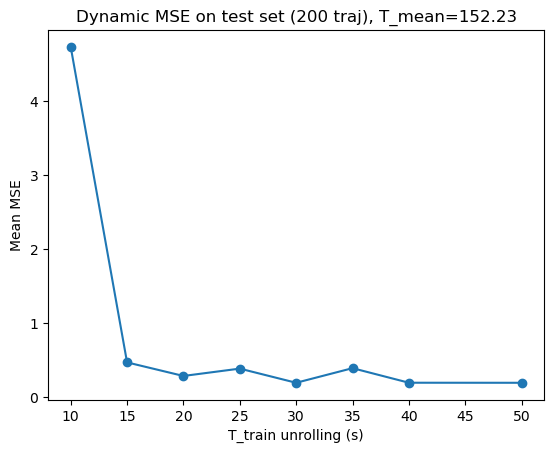

In [127]:
plt.figure()
plt.plot([5,10,15,20,25,30,35,40,50][1:], mean_mses[1:], label='MSE on test set (200 traj)', marker='o')
plt.xlabel('T_train unrolling (s)')
plt.ylabel('Mean MSE')
plt.title(f'Dynamic MSE on test set (200 traj), T_mean={mean_T}')

In [128]:
mean_mses

[6.0678018e+28,
 4.7276263,
 0.47219315,
 0.28914565,
 0.38827574,
 0.19723636,
 0.39427468,
 0.1979562,
 0.19722405]

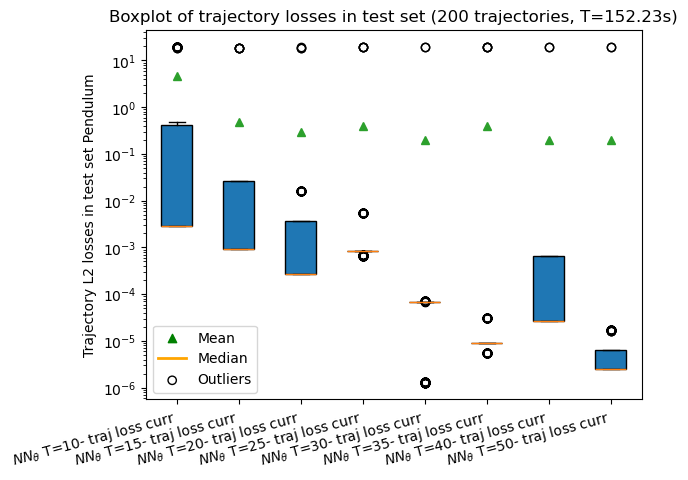

In [194]:
# boxplot meilleur

losses_traj = [
    metrics_aug_none10["L2_dynamic"],
    metrics_aug_none15["L2_dynamic"],
    metrics_aug_none20["L2_dynamic"],
    metrics_aug_none25["L2_dynamic"],
    metrics_aug_none30["L2_dynamic"],
    metrics_aug_none35["L2_dynamic"],
    metrics_aug_none40["L2_dynamic"],
    metrics_aug_none50["L2_dynamic"],
]
labels = [
          r'$NN_{\theta}$ T=10- traj loss curr',
          r'$NN_{\theta}$ T=15- traj loss curr',
          r'$NN_{\theta}$ T=20- traj loss curr',
          r'$NN_{\theta}$ T=25- traj loss curr',
          r'$NN_{\theta}$ T=30- traj loss curr',
          r'$NN_{\theta}$ T=35- traj loss curr',
          r'$NN_{\theta}$ T=40- traj loss curr',
          r'$NN_{\theta}$ T=50- traj loss curr',]
#colors = ['peachpuff', 'orange', 'tomato']

fig, ax = plt.subplots()
ax.set_ylabel('Trajectory L2 losses in test set Pendulum')
#ax.set_ylim(0.005,0.5)
ax.set_yscale('log')


# orientation en biais
bplot = ax.boxplot(
    losses_traj,
    patch_artist=True,
    showmeans=True
)

ax.set_xticks([1, 2, 3, 4,5,6,7,8])
ax.set_xticklabels(labels, rotation=15, ha='right')
# dummy legend
mean_legend = plt.scatter([], [], color='green', marker='^', label='Mean')
median_legend = plt.Line2D([0], [0], color='orange', linewidth=2, label='Median')
outlier_legend = plt.scatter([],[], marker= 'o',edgecolors='black', facecolors='none', label='Outliers')

ax.legend(handles=[mean_legend, median_legend, outlier_legend], loc='lower left')
# fill with colors
# for patch, color in zip(bplot['boxes'], colors):
#     patch.set_facecolor(color)
plt.title(f"Boxplot of trajectory losses in test set (200 trajectories, T={mean_T}s)")
plt.show()

In [121]:
periods_Seen = np.array([5,10,15,20,25,30,35,40,50])/12
for i,k in enumerate([5,10,15,20,25,30,35,40,50]):
    print(f"Pendulum periods seen for {k} seconds of training: {periods_Seen[i]}s")

Pendulum periods seen for 5 seconds of training: 0.4166666666666667s
Pendulum periods seen for 10 seconds of training: 0.8333333333333334s
Pendulum periods seen for 15 seconds of training: 1.25s
Pendulum periods seen for 20 seconds of training: 1.6666666666666667s
Pendulum periods seen for 25 seconds of training: 2.0833333333333335s
Pendulum periods seen for 30 seconds of training: 2.5s
Pendulum periods seen for 35 seconds of training: 2.9166666666666665s
Pendulum periods seen for 40 seconds of training: 3.3333333333333335s
Pendulum periods seen for 50 seconds of training: 4.166666666666667s


(-10.0, 2.5)

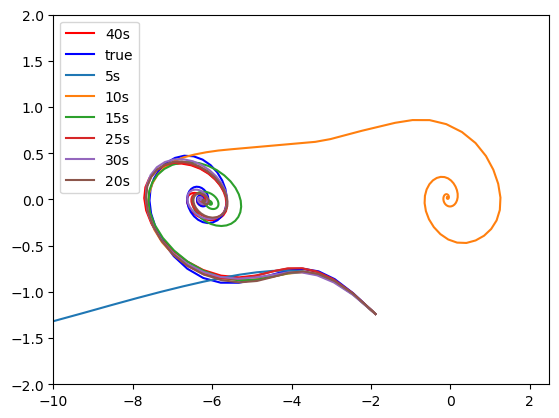

In [92]:
k=13
plt.plot(data_aug_none40["y_pred"][k][0,:], data_aug_none40["y_pred"][k][1,:], label='40s', color='red')
plt.plot(data_aug_none40["y_true"][k][0,:], data_aug_none40["y_true"][k][1,:], label='true', color='blue')
plt.plot(data_aug_none5["y_pred"][k][0,:], data_aug_none5["y_pred"][k][1,:], label='5s')
plt.plot(data_aug_none10["y_pred"][k][0,:], data_aug_none10["y_pred"][k][1,:], label='10s')
plt.plot(data_aug_none15["y_pred"][k][0,:], data_aug_none15["y_pred"][k][1,:], label='15s')
plt.plot(data_aug_none25["y_pred"][k][0,:], data_aug_none25["y_pred"][k][1,:], label='25s')
plt.plot(data_aug_none30["y_pred"][k][0,:], data_aug_none30["y_pred"][k][1,:], label='30s')
plt.plot(data_aug_none20["y_pred"][k][0,:], data_aug_none20["y_pred"][k][1,:], label='20s')
plt.legend()
plt.ylim(-2,2)
plt.xlim(-10,2.5)


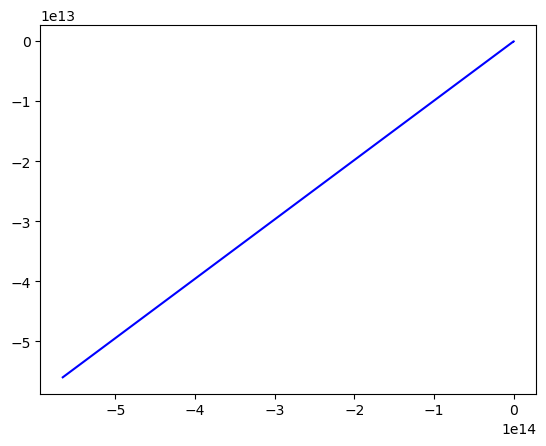

In [63]:
plt.plot(data_aug_none5["y_pred"][k][0,:], data_aug_none5["y_pred"][k][1,:], label='true', color='blue')

### Fa prime full trajectories

In [112]:
# /Users/mayajanvier/jax-phynity/data/lipschitz_init/none_Fa_prime_aug_20_21_2lnfi7xs/model_5.633e-03.eqx
model_name = 'model_5.633e-03.eqx'
exp_name = 'none_Fa_prime_aug_20_21_2lnfi7xs'
data_path = 'data/lipschitz_init'
model_phy_option = 'none_Fa_prime'
model_aug_option = True
dataset_name = 'pendulum'
integration_method = 'RK4'
duration = 20
dt_num = 0.5
aug_none_Fa_prime20_l10_tau10_nocurr = load_pendulum(model_name,exp_name, data_path, model_phy_option, model_aug_option, dataset_name, integration_method, dt_num=dt_num, duration=duration)

data/lipschitz_init/none_Fa_prime_aug_20_21_2lnfi7xs/model_5.633e-03.eqx
0.5 1


In [113]:
# # /Users/mayajanvier/jax-phynity/data/lipschitz_init/none_Fa_prime_aug_40_33_t7uthp7u/model_2.493e-03.eqx
model_name = 'model_2.493e-03.eqx'
exp_name = 'none_Fa_prime_aug_40_33_t7uthp7u'
data_path = 'data/lipschitz_init'
model_phy_option = 'none_Fa_prime'
model_aug_option = True
dataset_name = 'pendulum'
integration_method = 'RK4'
duration = 40
dt_num = 0.5
aug_none_Fa_prime40_l10_tau10_nocurr = load_pendulum(model_name,exp_name, data_path, model_phy_option, model_aug_option, dataset_name, integration_method, dt_num=dt_num, duration=duration)

data/lipschitz_init/none_Fa_prime_aug_40_33_t7uthp7u/model_2.493e-03.eqx
0.5 1


In [115]:
F_aug_none_Fa_prime20_l10_tau10_nocurr = aug_none_Fa_prime20_l10_tau10_nocurr.derivative_estimator
F_aug_none_Fa_prime40_l10_tau10_nocurr = aug_none_Fa_prime40_l10_tau10_nocurr.derivative_estimator

In [130]:
data_aug_none_Fa_prime20_l10_tau10_nocurr = compute_trajectories(F_aug_none_Fa_prime20_l10_tau10_nocurr, y0s, dt_truth=0.5, dt_factor=1, t1=200)
data_aug_none_Fa_prime40_l10_tau10_nocurr = compute_trajectories(F_aug_none_Fa_prime40_l10_tau10_nocurr, y0s, dt_truth=0.5, dt_factor=1, t1=200)

In [131]:
metrics_aug_none_Fa_prime20_l10_tau10_nocurr = compute_metrics(data_aug_none_Fa_prime20_l10_tau10_nocurr, compute_phy=False)
metrics_aug_none_Fa_prime40_l10_tau10_nocurr = compute_metrics(data_aug_none_Fa_prime40_l10_tau10_nocurr, compute_phy=False)

In [158]:
lip_data_aug_none_Fa_prime20_l10_tau10_nocurr = compute_jacobian_test(aug_none_Fa_prime20_l10_tau10_nocurr)
lip_data_aug_none_Fa_prime40_l10_tau10_nocurr = compute_jacobian_test(aug_none_Fa_prime40_l10_tau10_nocurr)

(2025, 2) (2,)
(2025, 2) (2,)


In [781]:
df_comp = pd.DataFrame({
    "20s curr": lip_data_aug_none20,
    "20s lip no curr": lip_data_aug_none_Fa_prime20_l10_tau10_nocurr,
    "40s curr": lip_data_aug_none40,
    "40s lip no curr": lip_data_aug_none_Fa_prime40_l10_tau10_nocurr,
    "true lip": lip_data_truth,
})
save_data_traj(df_comp, "data/lipschitz_curriculum/lip_nocurr_20_40s.csv")

In [172]:
def F_y(y):
    return jnp.array([y[1], -((2*jnp.pi/12)**2) * jnp.sin(y[0]) - 0.2*y[1]])

def compute_jacobian_true():
    y_list = []
    for i,data in enumerate(test):
        states = jnp.array(data['states'])
        for j in range(states.shape[2]):
            y_list.append(states[0,:,j])
        if i == 24:
            break
    y_list = np.array(y_list)
    print(y_list.shape, y_list[0].shape)
    jac_norm_aug = []
    for y0 in y_list:
        y0 = np.array(y0)
        jac_norm_aug.append(np.linalg.norm(jacobian(F_y, y0)))
    return jac_norm_aug

In [173]:
lip_data_truth = compute_jacobian_true()

(2025, 2) (2,)


In [184]:
df_true = pd.DataFrame({
    "truth": lip_data_truth,
})

In [726]:
save_data_traj(df_true, "data/lipschitz_curriculum/lipschitz_truth.csv")

In [178]:
df_comp = pd.DataFrame({
    "20s curr": lip_data_aug_none20,
    "20s lip no curr": lip_data_aug_none_Fa_prime20_l10_tau10_nocurr,
    "40s curr": lip_data_aug_none40,
    "40s lip no curr": lip_data_aug_none_Fa_prime40_l10_tau10_nocurr,
})

In [782]:
# true models no curr on which to compare lip no curr
# /Users/mayajanvier/jax-phynity/data/lipschitz_init/none_aug_40_7_g5si31tr/model_5.308e-01.eqx
model_name = 'model_5.308e-01.eqx'
exp_name = 'none_aug_40_7_g5si31tr'
data_path = 'data/lipschitz_init'   
model_phy_option = 'none'
model_aug_option = True
dataset_name = 'pendulum'
integration_method = 'RK4'
duration = 40
dt_num = 0.5
aug_none_40_nocurr = load_pendulum(model_name,exp_name, data_path, model_phy_option, model_aug_option, dataset_name, integration_method, dt_num=dt_num, duration=duration)

# /Users/mayajanvier/jax-phynity/data/lipschitz_init/none_aug_20_19_k9e2ej4f/model_1.495e-02.eqx
model_name = 'model_1.495e-02.eqx'
exp_name = 'none_aug_20_19_k9e2ej4f'
data_path = 'data/lipschitz_init'
model_phy_option = 'none'
model_aug_option = True
dataset_name = 'pendulum'
integration_method = 'RK4'
duration = 20
dt_num = 0.5
aug_none_20_nocurr = load_pendulum(model_name,exp_name, data_path, model_phy_option, model_aug_option, dataset_name, integration_method, dt_num=dt_num, duration=duration)

data/lipschitz_init/none_aug_40_7_g5si31tr/model_5.308e-01.eqx
0.5 1
data/lipschitz_init/none_aug_20_19_k9e2ej4f/model_1.495e-02.eqx
0.5 1


In [783]:
data_aug_none_40_nocurr = compute_trajectories(aug_none_40_nocurr.derivative_estimator, y0s, dt_truth=0.5, dt_factor=1, t1=200)

In [ ]:
data_aug_none_20_nocurr = compute_trajectories(aug_none_20_nocurr.derivative_estimator, y0s, dt_truth=0.5, dt_factor=1, t1=200)

Text(0.5, 1.0, 'true jacobian norms')

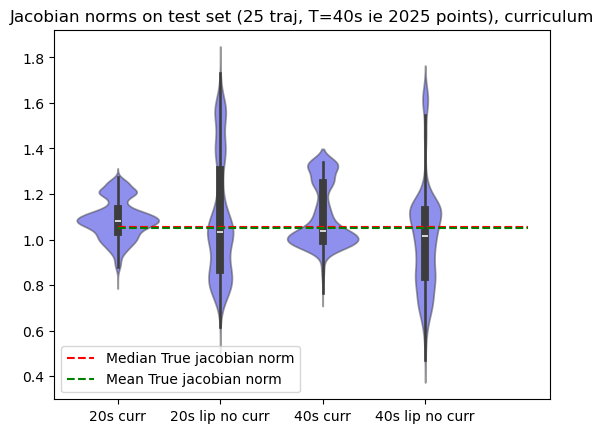

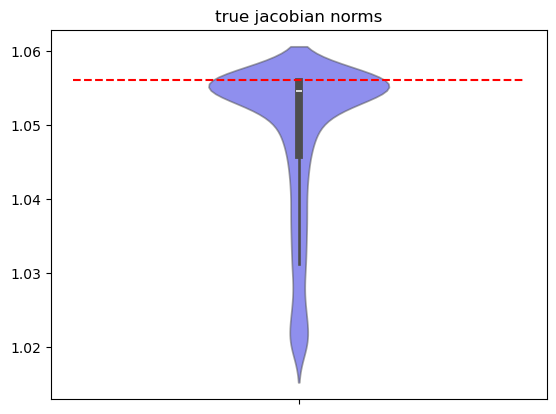

In [310]:
sns.violinplot(df_comp, color='blue', alpha=0.5)
plt.title('Jacobian norms on test set (25 traj, T=40s ie 2025 points), curriculum')
plt.hlines(df_true.median(), 0, 4, linestyles='dashed', color='red', label='Median True jacobian norm')
plt.hlines(df_true.mean(), 0, 4, linestyles='dashed', color='green', label='Mean True jacobian norm')
plt.legend()
plt.figure()
sns.violinplot(lip_data_truth, color='blue', alpha=0.5)
plt.hlines(L_true, -1, 1, linestyles='dashed', color='red', label='True Lipschitz constant')
plt.title("true jacobian norms")

In [698]:
df_comp["true"] = df_true
df_L_diff_liploss = df_comp.apply(lambda x: np.abs(x- x["true"]), axis=1)
df_L_diff_liploss

,20s curr,20s lip no curr,40s curr,40s lip no curr,true
0,0.051708,0.079425,0.155396,0.092775,0.0
1,0.016341,0.023618,0.028232,0.035777,0.0
2,0.162298,0.088590,0.232615,0.030357,0.0
3,0.024422,0.140278,0.229407,0.056314,0.0
4,0.081664,0.119122,0.077290,0.052921,0.0
...,...,...,...,...,...
2020,0.018475,0.306150,0.075724,0.387691,0.0
2021,0.018466,0.306160,0.066183,0.430574,0.0
2022,0.018460,0.306166,0.055556,0.416707,0.0
2023,0.018458,0.306168,0.051659,0.463914,0.0


Text(0.5, 1.0, 'L1 error on jacobian norms on test set (25 traj, T=40s ie 2025 points), curriculum')

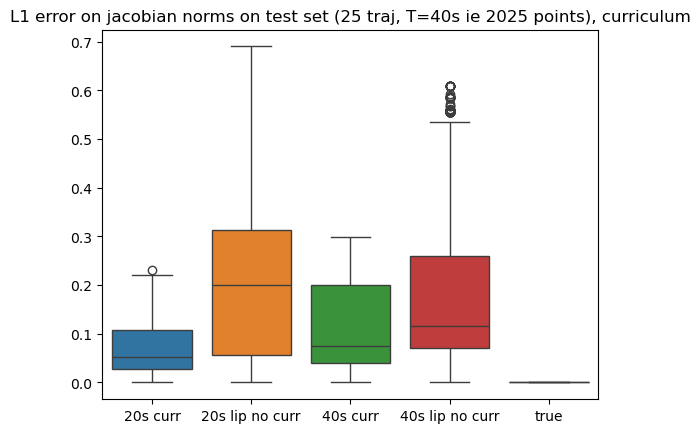

In [700]:
sns.boxplot(df_L_diff_liploss)
plt.title("L1 error on jacobian norms on test set (25 traj, T=40s ie 2025 points), curriculum")

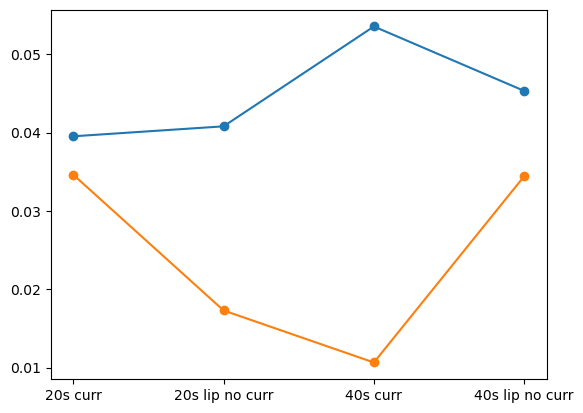

In [695]:
plt.plot(diff_L_mean_liploss, label='|L_theta_mean - L_mean|', marker='o')
plt.plot(diff_L_median_liploss, label='|L_theta_median - L_median|', marker='o')

In [309]:
L_true, np.array(lip_data_truth).max(), np.array(lip_data_truth).min()

(1.0560119959898109, 1.056012, 1.0198119)

In [206]:
# get indices of trajectory 
outliers_20 = metrics_aug_none20.where(metrics_aug_none20["L2_dynamic"] > 1).dropna().index
outliers_40 = metrics_aug_none40.where(metrics_aug_none40["L2_dynamic"] > 1).dropna().index
outliers_50 = metrics_aug_none50.where(metrics_aug_none50["L2_dynamic"] > 1).dropna().index

In [207]:
outliers_20, outliers_40, outliers_50

(Index([22, 38, 187], dtype='int64'),
 Index([22, 38], dtype='int64'),
 Index([38, 187], dtype='int64'))

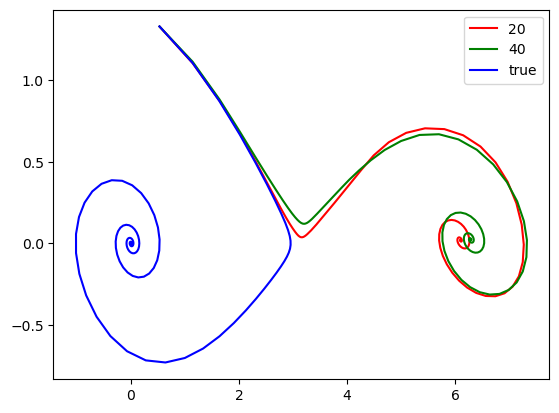

In [236]:
plt.plot(data_aug_none20["y_pred"][outliers_20[0]][0,:], data_aug_none20["y_pred"][outliers_20[0]][1,:], label='20', color='red')
plt.plot(data_aug_none40["y_pred"][outliers_40[0]][0,:], data_aug_none40["y_pred"][outliers_40[0]][1,:], label='40', color='green')
plt.plot(data_aug_none20["y_true"][outliers_20[0]][0,:], data_aug_none20["y_true"][outliers_20[0]][1,:], label='true', color='blue')
plt.legend()


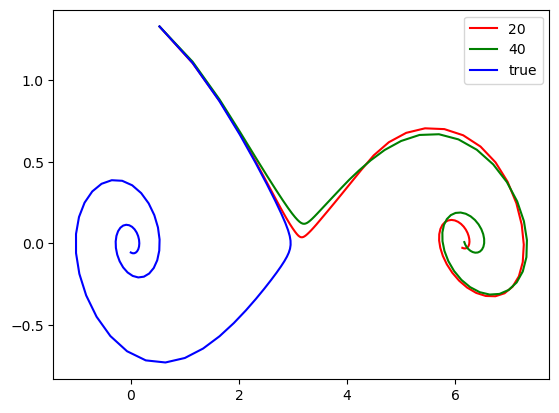

In [237]:
plt.plot(data_aug_none20["y_pred"][outliers_20[0]][0,:80], data_aug_none20["y_pred"][outliers_20[0]][1,:80], label='20', color='red')
plt.plot(data_aug_none40["y_pred"][outliers_40[0]][0,:80], data_aug_none40["y_pred"][outliers_40[0]][1,:80], label='40', color='green')
plt.plot(data_aug_none20["y_true"][outliers_20[0]][0,:80], data_aug_none20["y_true"][outliers_20[0]][1,:80], label='true', color='blue')
plt.legend()


In [312]:
def loss_Fa_prime(model, y):
    print('loss_Fa_prime')
    loss_prime = 0.0
    for k_batch in range(y.shape[0]):
        y_in = y[k_batch,:,:]
        y_in = rearrange(y_in, 'nc T -> (T) nc')
        aug_deriv = jax.vmap(model.model_aug)(y_in) 
        F_prime = jnp.abs(aug_deriv[1:,:]-aug_deriv[:-1,:]) / jnp.abs(y_in[1:,:] - y_in[:-1,:])
    return F_prime

In [316]:
traj_true = data_aug_none20["y_true"].to_numpy()

(200,)

In [517]:
def compute_loss_Fa_prime_predict(model, metrics_pred):
    fa_primes= []
    for k in range(traj_true.shape[0]):
        traj = metrics_pred["y_pred"][k]   #traj_true[k]
        y_in = rearrange(traj, 'nc T -> (T) nc')
        aug_deriv = jax.vmap(model.model_aug)(y_in)
        F_prime =  jnp.abs(aug_deriv[1:,:]-aug_deriv[:-1,:]) / jnp.abs(y_in[1:,:] - y_in[:-1,:])
        fa_primes.append(F_prime)
    return np.array(fa_primes)

In [523]:
fa_primes_aug_none10_predict = compute_loss_Fa_prime_predict(aug_none10, data_aug_none10)
fa_primes_aug_none15_predict = compute_loss_Fa_prime_predict(aug_none15, data_aug_none15)
fa_primes_aug_none20_predict = compute_loss_Fa_prime_predict(aug_none20, data_aug_none20)
fa_primes_aug_none25_predict = compute_loss_Fa_prime_predict(aug_none25, data_aug_none25)
fa_primes_aug_none30_predict = compute_loss_Fa_prime_predict(aug_none30, data_aug_none30)
fa_primes_aug_none35_predict = compute_loss_Fa_prime_predict(aug_none35, data_aug_none35)
fa_primes_aug_none40_predict = compute_loss_Fa_prime_predict(aug_none40, data_aug_none40)
fa_primes_aug_none50_predict = compute_loss_Fa_prime_predict(aug_none50, data_aug_none50)

In [524]:
df_fa_primes_predict  = pd.DataFrame({
    "10s": fa_primes_aug_none10_predict.mean(axis=2)[:,:80].flatten(),
    "15s": fa_primes_aug_none15_predict.mean(axis=2)[:,:80].flatten(),
    "20s": fa_primes_aug_none20_predict.mean(axis=2)[:,:80].flatten(),
    "25s": fa_primes_aug_none25_predict.mean(axis=2)[:,:80].flatten(),
    "30s": fa_primes_aug_none30_predict.mean(axis=2)[:,:80].flatten(),
    "35s": fa_primes_aug_none35_predict.mean(axis=2)[:,:80].flatten(),
    "40s": fa_primes_aug_none40_predict.mean(axis=2)[:,:80].flatten(),
    "50s": fa_primes_aug_none50_predict.mean(axis=2)[:,:80].flatten(),
})

In [521]:
fa_primes_aug_none_Fa_prime20_predict = compute_loss_Fa_prime_predict(aug_none_Fa_prime20_l10_tau10_nocurr, data_aug_none_Fa_prime20_l10_tau10_nocurr)
fa_primes_aug_none_Fa_prime40_predict = compute_loss_Fa_prime_predict(aug_none_Fa_prime40_l10_tau10_nocurr, data_aug_none_Fa_prime40_l10_tau10_nocurr)

In [525]:
df_fa_primes_comp = pd.DataFrame({
    "20s curr": fa_primes_aug_none20_predict.mean(axis=2)[:,:80].flatten(),
    "20s lip no curr": fa_primes_aug_none_Fa_prime20_predict.mean(axis=2)[:,:80].flatten(),
    "40s curr": fa_primes_aug_none40_predict.mean(axis=2)[:,:80].flatten(),
    "40s lip no curr": fa_primes_aug_none_Fa_prime40_predict.mean(axis=2)[:,:80].flatten(),
})

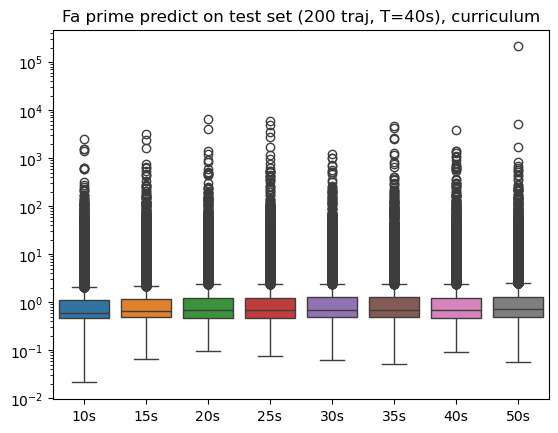

In [529]:
sns.boxplot(df_fa_primes_predict)
plt.title('Fa prime predict on test set (200 traj, T=40s), curriculum')
plt.yscale('log')

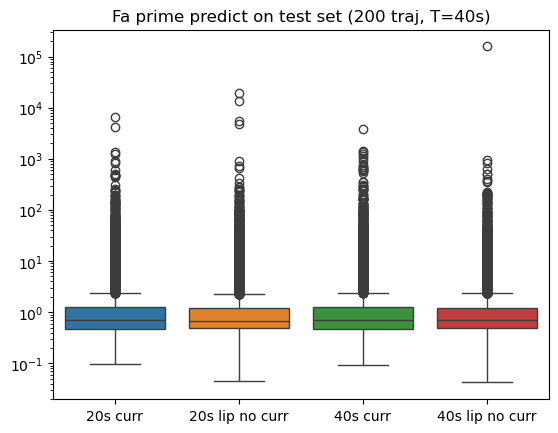

In [530]:
sns.boxplot(df_fa_primes_comp)
plt.title('Fa prime predict on test set (200 traj, T=40s)')
plt.yscale('log')

In [548]:
fa_primes_aug_none10_predict.mean(axis=2)[:,:80].shape

(200, 80)

In [569]:
fa_primes_aug_none15_predict.mean(axis=2)[:,:79].flatten().mean()

2.7550583

In [570]:
df_fa_primes_predict_mean = {
    "10s": fa_primes_aug_none10_predict.mean(axis=2)[:,:80].flatten().mean(),
    "15s": fa_primes_aug_none15_predict.mean(axis=2)[:,:79].flatten().mean(),
    "20s": fa_primes_aug_none20_predict.mean(axis=2)[:,:80].flatten().mean(),
    "25s": fa_primes_aug_none25_predict.mean(axis=2)[:,:80].flatten().mean(),
    "30s": fa_primes_aug_none30_predict.mean(axis=2)[:,:80].flatten().mean(),
    "35s": fa_primes_aug_none35_predict.mean(axis=2)[:,:80].flatten().mean(),
    "40s": fa_primes_aug_none40_predict.mean(axis=2)[:,:80].flatten().mean(),
    "50s": fa_primes_aug_none50_predict.mean(axis=2)[:,:80].flatten().mean(),
}

In [596]:
df_fa_primes_true_predict.mean()- df_fa_primes_predict.mean()

10s    0.395362
15s         NaN
20s    0.006692
25s    0.070880
30s    0.021148
35s    0.009957
40s    0.129097
50s    0.178982
dtype: float32

In [599]:
fa_primes_true_predict_mean = df_fa_primes_true_predict.mean().to_numpy()
fa_primes_true_predict_mean[1] = compute_loss_Fa_prime_true_predict(metrics_aug_none15).mean(axis=2)[:,:75].flatten().mean()
fa_primes_true_predict_mean 

array([ 2.933611 ,  2.9307382,  3.2258344,  3.8694513,  2.5726984,
        3.4130967,  3.3935905, 16.269299 ], dtype=float32)

In [613]:
fa_primes_predict_mean = list(df_fa_primes_predict_mean.values())

In [619]:
diff_fa_prime_predict = pd.DataFrame({
    "10s": np.abs(fa_primes_aug_none10_predict.mean(axis=2)[:,:80].flatten()-df_fa_primes_true_predict["10s"]),
    "15s": np.abs(fa_primes_aug_none15_predict.mean(axis=2)[:,:80].flatten()-df_fa_primes_true_predict["15s"]),
    "20s": np.abs(fa_primes_aug_none20_predict.mean(axis=2)[:,:80].flatten()-df_fa_primes_true_predict["20s"]),
    "25s": np.abs(fa_primes_aug_none25_predict.mean(axis=2)[:,:80].flatten()-df_fa_primes_true_predict["25s"]),
    "30s": np.abs(fa_primes_aug_none30_predict.mean(axis=2)[:,:80].flatten()-df_fa_primes_true_predict["30s"]),
    "35s": np.abs(fa_primes_aug_none35_predict.mean(axis=2)[:,:80].flatten()-df_fa_primes_true_predict["35s"]),
    "40s": np.abs(fa_primes_aug_none40_predict.mean(axis=2)[:,:80].flatten()-df_fa_primes_true_predict["40s"]),
    "50s": np.abs(fa_primes_aug_none50_predict.mean(axis=2)[:,:80].flatten()-df_fa_primes_true_predict["50s"]),
})

Text(0.5, 1.0, 'diff fa prime on pred trajectories, T=40s')

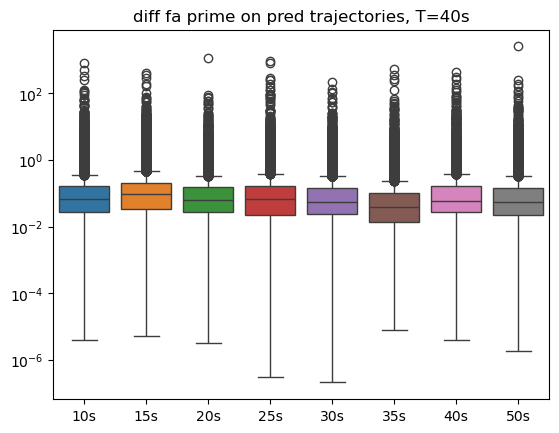

In [620]:
sns.boxplot(diff_fa_prime_predict)
plt.yscale('log')
plt.title('diff fa prime on pred trajectories, T=40s')

Text(0.5, 1.0, 'Fa prime mean on test set (200 traj, T=40s), curriculum')

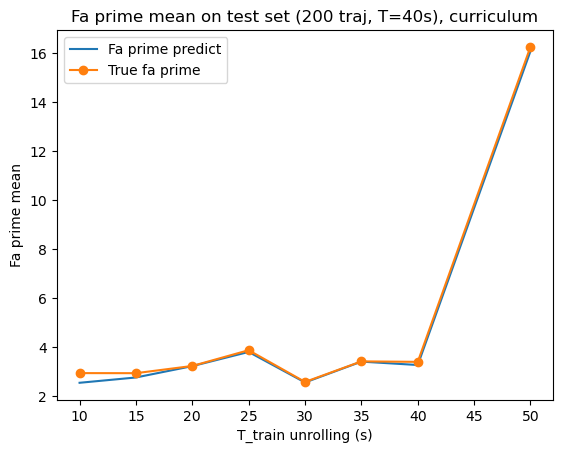

In [637]:
plt.plot([10,15,20,25,30,35,40,50],df_fa_primes_predict_mean.values(), label="Fa prime predict")
plt.plot([10,15,20,25,30,35,40,50], fa_primes_true_predict_mean , marker='o', label='True fa prime')
#plt.plot([20,40], [fa_primes_aug_none_Fa_prime20_predict.mean(axis=2)[:,:80].flatten().mean(), fa_primes_aug_none_Fa_prime40_predict.mean(axis=2)[:,:80].flatten().mean()], marker='o', label="lip loss")
#plt.hlines(np.mean(fa_primes_true.mean(axis=2)[:,:80]), 10, 50, linestyles='dashed', color='red', label='Median True fa_prime')
#plt.ylim(0,4)
#plt.yscale("log")
plt.legend()
plt.xlabel('T_train unrolling (s)')
plt.ylabel('Fa prime mean')
plt.title("Fa prime mean on test set (200 traj, T=40s), curriculum")

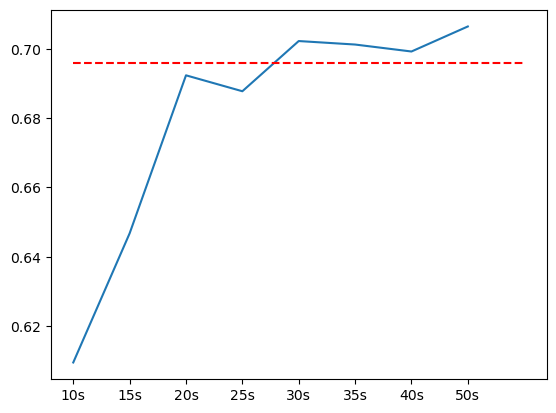

In [574]:
plt.plot(df_fa_primes_predict.median(axis=0))
plt.hlines(np.median(fa_primes_true.mean(axis=2)[:,:80]), 0, 8, linestyles='dashed', color='red', label='Median True fa_prime')


In [ ]:
mean_fa_primes_predict = df_fa_primes_predict.mean(axis=0)

In [342]:
def compute_loss_Fa_prime(model):
    fa_primes= []
    for k in range(traj_true.shape[0]):
        traj = traj_true[k]
        y_in = rearrange(traj, 'nc T -> (T) nc')
        aug_deriv = jax.vmap(model.model_aug)(y_in)
        F_prime =  jnp.abs(aug_deriv[1:,:]-aug_deriv[:-1,:]) / jnp.abs(y_in[1:,:] - y_in[:-1,:])
        fa_primes.append(F_prime)
    return np.array(fa_primes)

def compute_loss_Fa_prime_true():
    fa_primes= []
    for k in range(traj_true.shape[0]):
        traj = traj_true[k]
        y_in = rearrange(traj, 'nc T -> (T) nc')
        aug_deriv = jax.vmap(F_y)(y_in)
        F_prime =  jnp.abs(aug_deriv[1:,:]-aug_deriv[:-1,:]) / jnp.abs(y_in[1:,:] - y_in[:-1,:])
        fa_primes.append(F_prime)
    return np.array(fa_primes)


        

In [576]:
def compute_loss_Fa_prime_true_predict(metrics):
    fa_primes= []
    for k in range(traj_true.shape[0]):
        traj =  metrics["y_pred"][k] #traj_true[k]
        y_in = rearrange(traj, 'nc T -> (T) nc')
        aug_deriv = jax.vmap(F_y)(y_in)
        F_prime =  jnp.abs(aug_deriv[1:,:]-aug_deriv[:-1,:]) / jnp.abs(y_in[1:,:] - y_in[:-1,:])
        fa_primes.append(F_prime)
    return np.array(fa_primes)

In [632]:
fa_primes_true_predict10 =compute_loss_Fa_prime_true_predict(metrics_aug_none10)
fa_primes_true_predict20 = compute_loss_Fa_prime_true_predict(metrics_aug_none20)

Text(0.5, 1.0, 'T_train=20s')

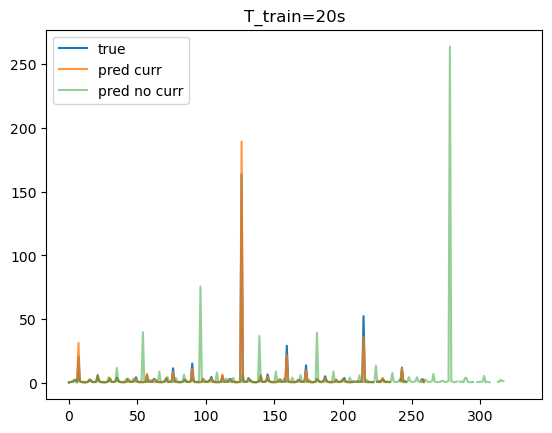

In [635]:
plt.plot(fa_primes_true_predict20[0].mean(axis=1), label='true')
plt.plot(fa_primes_aug_none20_predict[0].mean(axis=1), label='pred curr', alpha=0.8)
plt.plot(fa_primes_aug_none_Fa_prime20_predict[0].mean(axis=1), label='pred no curr', alpha=0.5)
plt.legend()
plt.title("T_train=20s")

In [585]:
fa_primes_true_predict10.mean(axis=2)[:,:80].flatten().mean()

2.933611

In [590]:
df_fa_primes_true_predict = pd.DataFrame({
    "10s": compute_loss_Fa_prime_true_predict(metrics_aug_none10).mean(axis=2)[:,:80].flatten(),
    "15s": compute_loss_Fa_prime_true_predict(metrics_aug_none15).mean(axis=2)[:,:80].flatten(),
    "20s":compute_loss_Fa_prime_true_predict(metrics_aug_none20).mean(axis=2)[:,:80].flatten(),
    "25s":compute_loss_Fa_prime_true_predict(metrics_aug_none25).mean(axis=2)[:,:80].flatten(),
    "30s":compute_loss_Fa_prime_true_predict(metrics_aug_none30).mean(axis=2)[:,:80].flatten(),
    "35s":compute_loss_Fa_prime_true_predict(metrics_aug_none35).mean(axis=2)[:,:80].flatten(),
    "40s":compute_loss_Fa_prime_true_predict(metrics_aug_none40).mean(axis=2)[:,:80].flatten(),
    "50s":compute_loss_Fa_prime_true_predict(metrics_aug_none50).mean(axis=2)[:,:80].flatten()
})

In [325]:
fa_primes_aug_none20 = compute_loss_Fa_prime(aug_none20)
fa_primes_aug_none20.shape

(200, 400, 2)

In [343]:
fa_primes_true = compute_loss_Fa_prime_true()

In [347]:
fa_primes_true[0].shape

(400, 2)

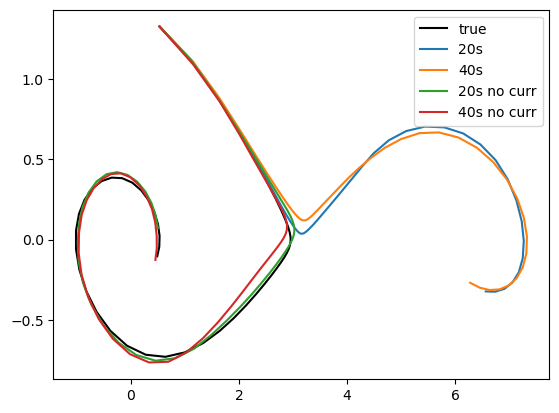

In [506]:
k=22
plt.plot(metrics_aug_none10["y_true"][k][0,:50], metrics_aug_none10["y_true"][k][1,:50], label="true", color="black")
plt.plot(metrics_aug_none20["y_pred"][k][0,:50], metrics_aug_none20["y_pred"][k][1,:50], label='20s')
plt.plot(metrics_aug_none40["y_pred"][k][0,:50], metrics_aug_none40["y_pred"][k][1,:50], label='40s')
plt.plot(metrics_aug_none_Fa_prime20_l10_tau10_nocurr["y_pred"][k][0,:50], metrics_aug_none_Fa_prime20_l10_tau10_nocurr["y_pred"][k][1,:50], label='20s no curr')
plt.plot(metrics_aug_none_Fa_prime40_l10_tau10_nocurr["y_pred"][k][0,:50], metrics_aug_none_Fa_prime40_l10_tau10_nocurr["y_pred"][k][1,:50], label='40s no curr')
plt.legend()

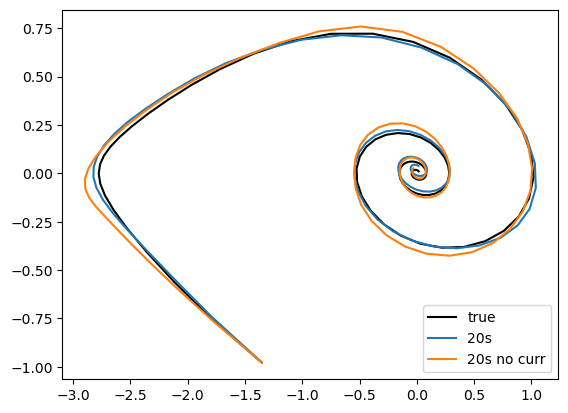

In [509]:
k=10
plt.plot(metrics_aug_none10["y_true"][k][0,:100], metrics_aug_none10["y_true"][k][1,:100], label="true", color="black")
plt.plot(metrics_aug_none20["y_pred"][k][0,:100], metrics_aug_none20["y_pred"][k][1,:100], label='20s')
#plt.plot(metrics_aug_none40["y_pred"][k][0,:50], metrics_aug_none40["y_pred"][k][1,:50], label='40s')
plt.plot(metrics_aug_none_Fa_prime20_l10_tau10_nocurr["y_pred"][k][0,:100], metrics_aug_none_Fa_prime20_l10_tau10_nocurr["y_pred"][k][1,:100], label='20s no curr')
#plt.plot(metrics_aug_none_Fa_prime40_l10_tau10_nocurr["y_pred"][k][0,:50], metrics_aug_none_Fa_prime40_l10_tau10_nocurr["y_pred"][k][1,:50], label='40s no curr')
plt.legend()

(0.0, 50.0)

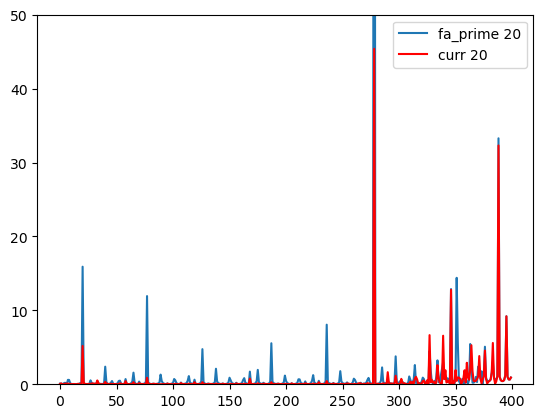

In [514]:
k=10
plt.plot(np.abs(fa_primes_aug_none_Fa_prime20[k].mean(axis=1)- fa_primes_true[k].mean(axis=1)), label="fa_prime 20")
#plt.plot(fa_primes_true[k].mean(axis=1), color="black", label="true")
plt.plot(np.abs(fa_primes_aug_none20[k].mean(axis=1) - fa_primes_true[k].mean(axis=1)), color="red", label="curr 20")
plt.legend()
plt.ylim(0,50)


In [326]:
fa_primes_aug_none10 = compute_loss_Fa_prime(aug_none10)
fa_primes_aug_none15 = compute_loss_Fa_prime(aug_none15)
fa_primes_aug_none20 = compute_loss_Fa_prime(aug_none20)
fa_primes_aug_none25 = compute_loss_Fa_prime(aug_none25)
fa_primes_aug_none30 = compute_loss_Fa_prime(aug_none30)
fa_primes_aug_none35 = compute_loss_Fa_prime(aug_none35)
fa_primes_aug_none40 = compute_loss_Fa_prime(aug_none40)
fa_primes_aug_none50 = compute_loss_Fa_prime(aug_none50)

In [443]:
fa_primes_aug_none_Fa_prime20 = compute_loss_Fa_prime(aug_none_Fa_prime20_l10_tau10_nocurr)
fa_primes_aug_none_Fa_prime40 = compute_loss_Fa_prime(aug_none_Fa_prime40_l10_tau10_nocurr)

In [366]:
fa_prime_df = pd.DataFrame({
    "10s": fa_primes_aug_none10.mean(axis=2)[:,:80].flatten(),
    "15s": fa_primes_aug_none15.mean(axis=2)[:,:80].flatten(),
    "20s": fa_primes_aug_none20.mean(axis=2)[:,:80].flatten(),
    "25s": fa_primes_aug_none25.mean(axis=2)[:,:80].flatten(),
    "30s": fa_primes_aug_none30.mean(axis=2)[:,:80].flatten(),
    "35s": fa_primes_aug_none35.mean(axis=2)[:,:80].flatten(),
    "40s": fa_primes_aug_none40.mean(axis=2)[:,:80].flatten(),
    "50s": fa_primes_aug_none50.mean(axis=2)[:,:80].flatten(),
})

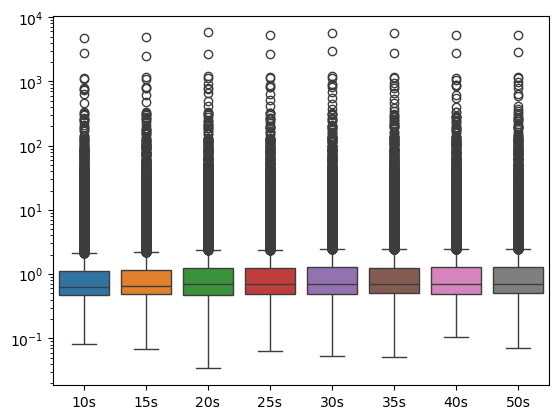

In [477]:
sns.boxplot(fa_prime_df)
plt.yscale('log')

In [364]:
fa_primes_aug_none10.mean(axis=2)[:,:80].flatten().max()

4778.511

In [375]:
mean_fa_primes = [
fa_primes_aug_none10.mean(axis=2)[:,:80].mean(),
fa_primes_aug_none15.mean(axis=2)[:,:80].mean(),
fa_primes_aug_none20.mean(axis=2)[:,:80].mean(),
fa_primes_aug_none25.mean(axis=2)[:,:80].mean(),
fa_primes_aug_none30.mean(axis=2)[:,:80].mean(),
fa_primes_aug_none35.mean(axis=2)[:,:80].mean(),
fa_primes_aug_none40.mean(axis=2)[:,:80].mean(),
fa_primes_aug_none50.mean(axis=2)[:,:80].mean(),
]

min_fa_primes = [
    fa_primes_aug_none10.mean(axis=2)[:,:80].min(),
    fa_primes_aug_none15.mean(axis=2)[:,:80].min(),
    fa_primes_aug_none20.mean(axis=2)[:,:80].min(),
    fa_primes_aug_none25.mean(axis=2)[:,:80].min(),
    fa_primes_aug_none30.mean(axis=2)[:,:80].min(),
    fa_primes_aug_none35.mean(axis=2)[:,:80].min(),
    fa_primes_aug_none40.mean(axis=2)[:,:80].min(),
    fa_primes_aug_none50.mean(axis=2)[:,:80].min(),
]
max_fa_primes = [
    fa_primes_aug_none10.mean(axis=2)[:,:80].max(),
    fa_primes_aug_none15.mean(axis=2)[:,:80].max(),
    fa_primes_aug_none20.mean(axis=2)[:,:80].max(),
    fa_primes_aug_none25.mean(axis=2)[:,:80].max(),
    fa_primes_aug_none30.mean(axis=2)[:,:80].max(),
    fa_primes_aug_none35.mean(axis=2)[:,:80].max(),
    fa_primes_aug_none40.mean(axis=2)[:,:80].max(),
    fa_primes_aug_none50.mean(axis=2)[:,:80].max(),
]

median_fa_primes = [
    np.median(fa_primes_aug_none10.mean(axis=2)[:,:80].flatten()),
    np.median(fa_primes_aug_none15.mean(axis=2)[:,:80].flatten()),
    np.median(fa_primes_aug_none20.mean(axis=2)[:,:80].flatten()),
    np.median(fa_primes_aug_none25.mean(axis=2)[:,:80].flatten()),
    np.median(fa_primes_aug_none30.mean(axis=2)[:,:80].flatten()),
    np.median(fa_primes_aug_none35.mean(axis=2)[:,:80].flatten()),
    np.median(fa_primes_aug_none50.mean(axis=2)[:,:80].flatten()),
    np.median(fa_primes_aug_none50.mean(axis=2)[:,:80].flatten()),

]



In [483]:
diff_fa_primes = pd.DataFrame({
    "10s": np.abs(fa_primes_aug_none10.mean(axis=2)[:,:80].flatten()-fa_primes_true[:,:80,:].mean(axis=2).flatten()),
    "15s":np.abs(fa_primes_aug_none15.mean(axis=2)[:,:80].flatten()-fa_primes_true[:,:80,:].mean(axis=2).flatten()),
    "20s":np.abs(fa_primes_aug_none20.mean(axis=2)[:,:80].flatten()-fa_primes_true[:,:80,:].mean(axis=2).flatten()),
    "25s":np.abs(fa_primes_aug_none25.mean(axis=2)[:,:80].flatten()-fa_primes_true[:,:80,:].mean(axis=2).flatten()),
    "30s":np.abs(fa_primes_aug_none30.mean(axis=2)[:,:80].flatten()-fa_primes_true[:,:80,:].mean(axis=2).flatten()),
    "35s":np.abs(fa_primes_aug_none35.mean(axis=2)[:,:80].flatten()-fa_primes_true[:,:80,:].mean(axis=2).flatten()),
    "40s":np.abs(fa_primes_aug_none40.mean(axis=2)[:,:80].flatten()-fa_primes_true[:,:80,:].mean(axis=2).flatten()),
    "50s":np.abs(fa_primes_aug_none50.mean(axis=2)[:,:80].flatten()-fa_primes_true[:,:80,:].mean(axis=2).flatten()),
})

In [444]:
diff_fa_primes_comp = pd.DataFrame({
    "20 curr":np.abs(fa_primes_aug_none20.mean(axis=2)[:,:80].flatten()-fa_primes_true[:,:80,:].mean(axis=2).flatten()),
    "20 lip no curr": np.abs(fa_primes_aug_none_Fa_prime20.mean(axis=2)[:,:80].flatten()-fa_primes_true[:,:80,:].mean(axis=2).flatten()),
    "40 curr":np.abs(fa_primes_aug_none40.mean(axis=2)[:,:80].flatten()-fa_primes_true[:,:80,:].mean(axis=2).flatten()),
    "40 lip no curr": np.abs(fa_primes_aug_none_Fa_prime40.mean(axis=2)[:,:80].flatten()-fa_primes_true[:,:80,:].mean(axis=2).flatten())
})

Text(0.5, 1.0, 'Diff fa prime over T=40s ')

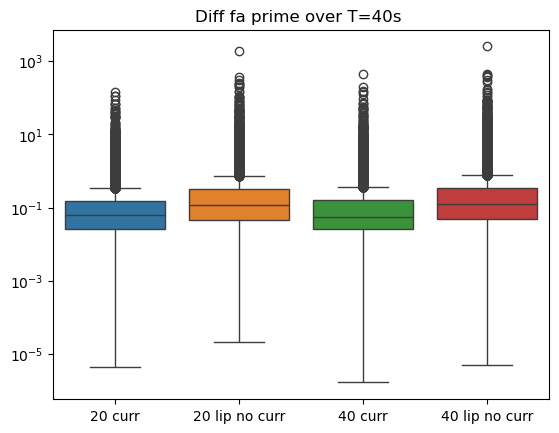

In [502]:
sns.boxplot(diff_fa_primes_comp)
plt.yscale("log")
plt.title("Diff fa prime over T=40s ")

In [492]:
fa_primes_true

array([[[0.3557487 , 0.02046605],
        [0.37664714, 0.5119407 ],
        [0.3102417 , 0.9681724 ],
        ...,
        [       inf, 0.20004521],
        [       inf, 0.1998002 ],
        [       inf, 0.20005518]],

       [[0.53735757, 0.02273419],
        [0.6882036 , 0.18912666],
        [0.90908873, 0.261836  ],
        ...,
        [0.9071671 , 0.10221077],
        [1.7043246 , 0.03914125],
        [9.777956  , 0.17196175]],

       [[0.5476555 , 0.14573999],
        [0.66043955, 0.29421464],
        [0.8055807 , 0.35510883],
        ...,
        [0.3494437 , 0.58454895],
        [0.54071075, 0.30702814],
        [0.84324664, 0.1251193 ]],

       ...,

       [[0.5805348 , 0.07467794],
        [0.7490075 , 0.210066  ],
        [1.0267859 , 0.26144263],
        ...,
        [1.186172  , 0.03112636],
        [2.8464866 , 0.1036863 ],
        [7.028171  , 0.23900801]],

       [[0.34315595, 0.08744361],
        [0.36929336, 0.49187928],
        [0.3034106 , 0.9840345 ],
        .

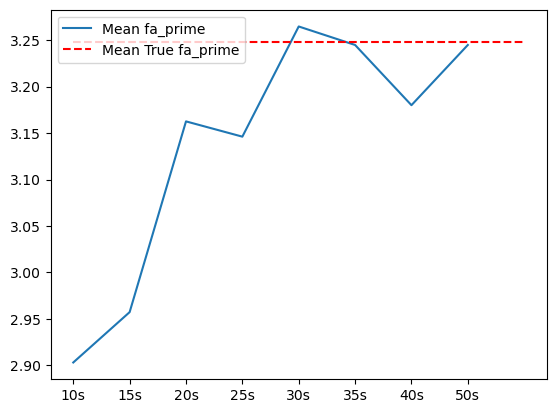

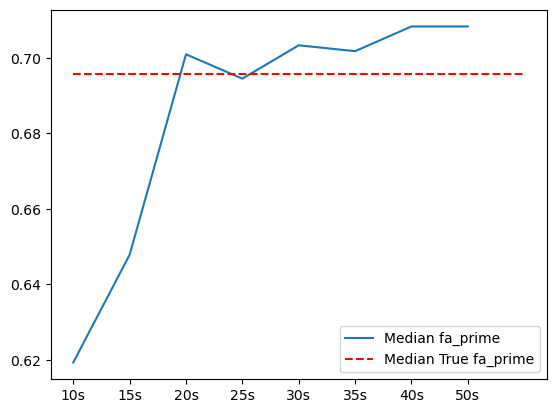

In [501]:
plt.plot(mean_fa_primes, label='Mean fa_prime')
plt.hlines(fa_primes_true.mean(axis=2)[:,:80].mean(), 0, 8, linestyles='dashed', color='red', label='Mean True fa_prime')
plt.xticks([0,1,2,3,4,5,6,7], ['10s', '15s', '20s', '25s', '30s', '35s', '40s', '50s'])
plt.legend()
plt.figure()
plt.plot(median_fa_primes, label='Median fa_prime')
plt.hlines(np.median(fa_primes_true.mean(axis=2)[:,:80]), 0, 8, linestyles='dashed', color='red', label='Median True fa_prime')
plt.xticks([0,1,2,3,4,5,6,7], ['10s', '15s', '20s', '25s', '30s', '35s', '40s', '50s'])
plt.legend()

In [440]:
def compute_dynamic_primes(data_prime):
    df = {}
    for k in range(data_prime.shape[0]):
        index_max = metrics_aug_none10["stationary_index"][k]
        df[k] = {
            "mean": data_prime.mean(axis=2)[k,:index_max].mean(),
            "median": np.median(data_prime.mean(axis=2)[k,:index_max].flatten())

        }
    return pd.DataFrame(df).T

In [442]:
data_prime_aug10 = compute_dynamic_primes(fa_primes_aug_none10)
data_prime_aug15 = compute_dynamic_primes(fa_primes_aug_none15)
data_prime_aug20 = compute_dynamic_primes(fa_primes_aug_none20)
data_prime_aug25 = compute_dynamic_primes(fa_primes_aug_none25)
data_prime_aug30 = compute_dynamic_primes(fa_primes_aug_none30)
data_prime_aug35 = compute_dynamic_primes(fa_primes_aug_none35)
data_prime_aug40 = compute_dynamic_primes(fa_primes_aug_none40)
data_prime_aug50 = compute_dynamic_primes(fa_primes_aug_none50)


In [421]:
diff_fa_primes_full = pd.DataFrame({
    "10s": np.abs(fa_primes_aug_none10.mean(axis=2).flatten()-fa_primes_true.mean(axis=2).flatten()),
    "15s":np.abs(fa_primes_aug_none15.mean(axis=2).flatten()-fa_primes_true.mean(axis=2).flatten()),
    "20s":np.abs(fa_primes_aug_none20.mean(axis=2).flatten()-fa_primes_true.mean(axis=2).flatten()),
    "25s":np.abs(fa_primes_aug_none25.mean(axis=2).flatten()-fa_primes_true.mean(axis=2).flatten()),
    "30s":np.abs(fa_primes_aug_none30.mean(axis=2).flatten()-fa_primes_true.mean(axis=2).flatten()),
    "35s":np.abs(fa_primes_aug_none35.mean(axis=2).flatten()-fa_primes_true.mean(axis=2).flatten()),
    "40s":np.abs(fa_primes_aug_none40.mean(axis=2).flatten()-fa_primes_true.mean(axis=2).flatten()),
    "50s":np.abs(fa_primes_aug_none50.mean(axis=2).flatten()-fa_primes_true.mean(axis=2).flatten()),
})

/var/folders/hd/6gcp429169ldrntwtps0b1_m0000gp/T/ipykernel_20349/359827548.py:2: RuntimeWarning: invalid value encountered in subtract
  "10s": np.abs(fa_primes_aug_none10.mean(axis=2).flatten()-fa_primes_true.mean(axis=2).flatten()),
/var/folders/hd/6gcp429169ldrntwtps0b1_m0000gp/T/ipykernel_20349/359827548.py:3: RuntimeWarning: invalid value encountered in subtract
  "15s":np.abs(fa_primes_aug_none15.mean(axis=2).flatten()-fa_primes_true.mean(axis=2).flatten()),
/var/folders/hd/6gcp429169ldrntwtps0b1_m0000gp/T/ipykernel_20349/359827548.py:4: RuntimeWarning: invalid value encountered in subtract
  "20s":np.abs(fa_primes_aug_none20.mean(axis=2).flatten()-fa_primes_true.mean(axis=2).flatten()),
/var/folders/hd/6gcp429169ldrntwtps0b1_m0000gp/T/ipykernel_20349/359827548.py:5: RuntimeWarning: invalid value encountered in subtract
  "25s":np.abs(fa_primes_aug_none25.mean(axis=2).flatten()-fa_primes_true.mean(axis=2).flatten()),
/var/folders/hd/6gcp429169ldrntwtps0b1_m0000gp/T/ipykernel_2034

In [396]:
mse_df = pd.DataFrame(
    {
    "10s":metrics_aug_none10["L2_dynamic"],
    "15s":metrics_aug_none15["L2_dynamic"],
    "20s":metrics_aug_none20["L2_dynamic"],
    "25s":metrics_aug_none25["L2_dynamic"],
    "30s":metrics_aug_none30["L2_dynamic"],
    "35s":metrics_aug_none35["L2_dynamic"],
    "40s":metrics_aug_none40["L2_dynamic"],
    "50s":metrics_aug_none50["L2_dynamic"],
    }
)

In [428]:
metrics_aug_none10["y0"][10], traj_true[10][:,0]

(array([-1.35319102, -0.97772956]),
 Array([-1.353191  , -0.97772956], dtype=float32))

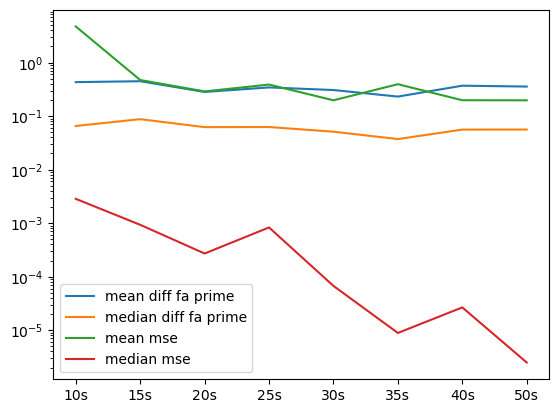

In [400]:
plt.plot(diff_fa_primes.mean(), label="mean diff fa prime")
plt.plot(mse_df.mean(), label="mean mse")
plt.plot(diff_fa_primes.median(), label="median diff fa prime")
plt.plot(mse_df.median(), label="median mse")
plt.legend()
plt.yscale("log")


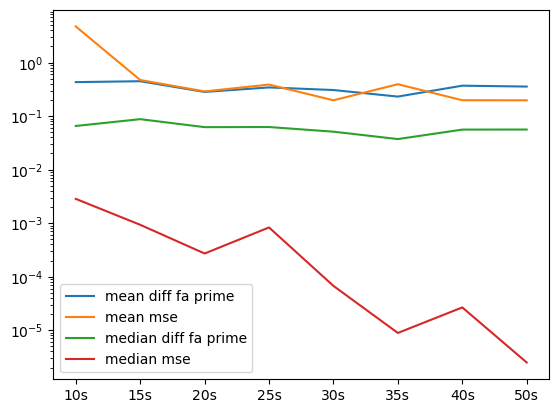

In [485]:
plt.plot(diff_fa_primes.mean(), label="mean diff fa prime")
plt.plot(mse_df.mean(), label="mean mse")
plt.plot(diff_fa_primes.median(), label="median diff fa prime")
plt.plot(mse_df.median(), label="median mse")
plt.legend()
plt.yscale("log")


In [679]:
df_L_diff.mean()[1:-1]

10s    0.093174
15s    0.091986
20s    0.072709
25s    0.087712
30s    0.080726
35s    0.071376
40s    0.111666
50s    0.111229
dtype: float32

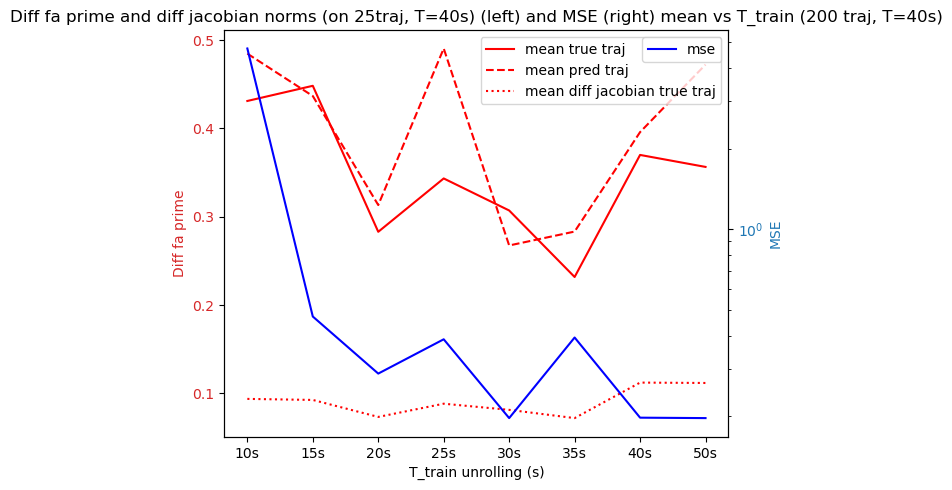

In [688]:
fig, ax1 = plt.subplots()

color = 'tab:red'
ax1.set_xlabel('T_train unrolling (s)')
ax1.set_ylabel('Diff fa prime', color=color)
ax1.plot(diff_fa_primes.mean(), label="mean true traj", color="red")
ax1.plot(diff_fa_prime_predict.mean(), label="mean pred traj", color="red", linestyle="--")
ax1.plot(df_L_diff.mean()[1:-1], label="mean diff jacobian true traj", color="red", linestyle=":")


#ax1.plot(diff_fa_primes.median(), label="median", color="red", linestyle="--")
#ax1.set_yscale("log")
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  # instantiate a second Axes that shares the same x-axis

color = 'tab:blue'
ax2.set_ylabel("MSE", color=color)  # we already handled the x-label with ax1
ax2.plot(mse_df.mean(), label="mse", color="blue")

#ax2.plot(mse_df.median(), label="median", color="blue", linestyle="--")
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_yscale("log")

ax2.legend()
ax1.legend()
fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.title("Diff fa prime and diff jacobian norms (on 25traj, T=40s) (left) and MSE (right) mean vs T_train (200 traj, T=40s)")
plt.show()

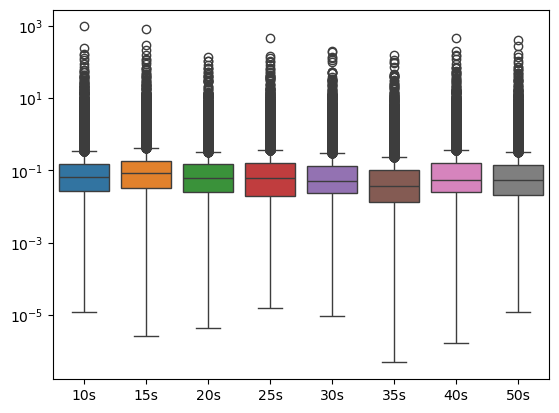

In [392]:
sns.boxplot(diff_fa_primes)
plt.yscale("log")

Text(0.5, 1.0, 'Mean Fa prime')

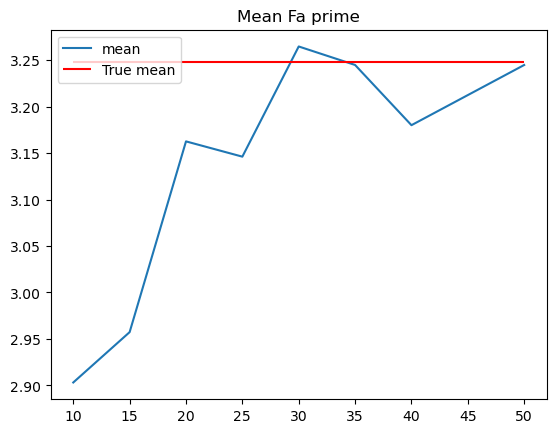

In [383]:
plt.plot([10,15,20,25,30,35,40,50], mean_fa_primes, label="mean")
plt.hlines(fa_primes_true[:,:80,:].mean(axis=2).flatten().mean(), 10,50, label="True mean", color="red")
plt.legend()
plt.title("Mean Fa prime")
#plt.yscale("log")

Text(0.5, 1.0, 'Median fa prime')

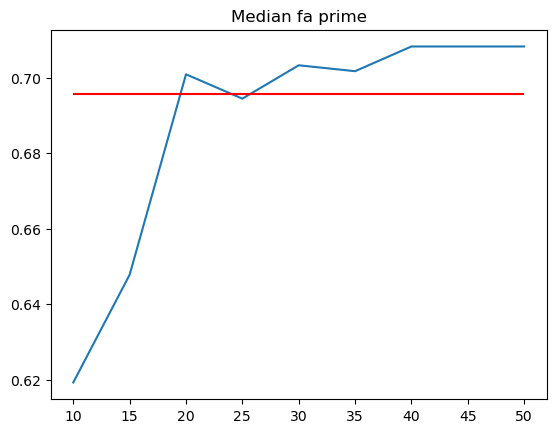

In [384]:
#plt.plot([10,15,20,25,30,35,40,50], min_fa_primes, label="min")
#plt.plot([10,15,20,25,30,35,40,50], max_fa_primes, label="max")
plt.plot([10,15,20,25,30,35,40,50], median_fa_primes, label="median")
plt.hlines(np.median(fa_primes_true[:,:80,:].mean(axis=2).flatten()), 10,50, label="True mean", color="red")
plt.title("Median fa prime")


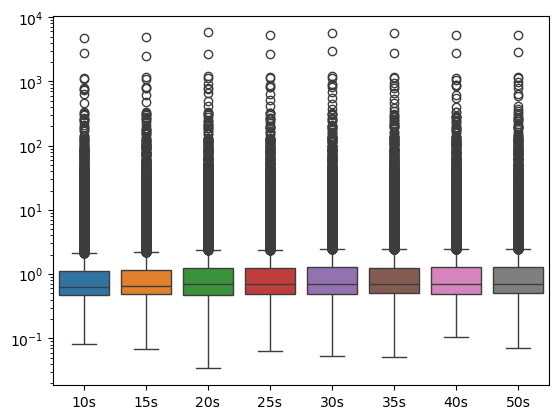

In [367]:
sns.boxplot(fa_prime_df)
plt.yscale("log")

### Fail Lip outliers 

In [222]:
## TODO Fail: qu'est ce que j'ai regardé ?
def compute_lip_outliers(indices, model):
    lip_data_outliers = []
    for i in indices:
        traj = metrics_aug_none20["y_true"][i]
        print(traj.shape)
        lip_traj = []
        for k in range(traj.shape[1]):
            print(k)
            lip_traj.append(np.linalg.norm(jacobian(model, traj[:,k])))  
        lip_data_outliers.append(lip_traj)
    return lip_data_outliers

lip_data_outliers_20 = compute_lip_outliers(outliers_20, aug_none20)
lip_data_outliers_40 = compute_lip_outliers(outliers_20, aug_none40)
lip_data_outliers_50 = compute_lip_outliers(outliers_20, aug_none50)

(2, 401)
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
2

Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x10bcb9c30>>
Traceback (most recent call last):
  File "/Users/mayajanvier/.conda/envs/jax_env/lib/python3.10/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(
KeyboardInterrupt: 


269
270
271
272
273
274
275
276
277
278
279
280
281
282
283
284
285
286
287
288
289
290
291
292
293
294
295
296
297
298
299
300
301
302
303
304
305
306
307
308
309
310
311
312
313
314
315
316
317
318
319
320
321
322
323
324
325
326
327
328
329
330
331
332
333
334
335
336
337
338
339
340
341
342
343
344
345
346
347
348
349
350
351
352
353
354
355
356
357
358
359
360
361
362
363
364
365
366
367
368
369
370
371
372
373
374
375
376
377
378
379
380
381
382
383
384
385
386
387
388
389
390
391
392
393
394
395
396
397
398
399
400
(2, 401)
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
1

Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x10bcb9c30>>
Traceback (most recent call last):
  File "/Users/mayajanvier/.conda/envs/jax_env/lib/python3.10/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(
KeyboardInterrupt: 


198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
277
278
279
280
281
282
283
284
285
286
287
288
289
290
291
292
293
294
295
296
297
298
299
300
301
302
303
304
305
306
307
308
309
310
311
312
313
314
315
316
317
318
319
320
321
322
323
324
325
326
327
328
329
330
331
332
333
334
335
336
337
338
339
340
341
342
343
344
345
346
347
348
349
350
351
352
353
354
355
356
357
358
359
360
361
362
363
364
365
366
367
368
369
370
371
372
373
374
375
376
377
378
379
380
381
382
383
384
385
386
387
388
389
390
391
392
393
394
395
396
397
398
399
400
(2, 401)
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62


In [227]:
lip_data_outliers_20 = np.array(lip_data_outliers_20)
lip_data_outliers_40 = np.array(lip_data_outliers_40)
lip_data_outliers_50 = np.array(lip_data_outliers_50)

In [239]:
df_lip_outliers_20 = pd.DataFrame({
    "22": lip_data_outliers_20[0],
    "38": lip_data_outliers_20[1],
    "187": lip_data_outliers_20[2],
})

df_lip_outliers_40 = pd.DataFrame({
    "22": lip_data_outliers_40[0],
    "38": lip_data_outliers_40[1],
    "187": lip_data_outliers_40[2],
})

df_lip_outliers_50 = pd.DataFrame({
    "22": lip_data_outliers_50[0],
    "38": lip_data_outliers_50[1],
    "187": lip_data_outliers_50[2],
})

In [255]:
np.linalg.norm(jacobian(aug_none50, data_aug_none20["y_pred"][outliers_20[0]][:,0])), np.linalg.norm(jacobian(aug_none_Fa_prime20_l10_tau10_nocurr, data_aug_none20["y_pred"][outliers_20[0]][:,0]))

(2999.9404, 593.4191)

In [245]:
np.linalg.norm(jacobian(aug_none50, data_aug_none20["y_pred"][0][:,0]))

14.252995

In [246]:
data_aug_none20["y_pred"][outliers_20[0]][:,0]

Array([0.5278256, 1.3292698], dtype=float32)

In [289]:
np.linalg.norm(jacobian(aug_none_Fa_prime20_l10_tau10_nocurr, data_aug_none20["y_pred"][0][:,0])), np.linalg.norm(jacobian(aug_none_Fa_prime20_l10_tau10_nocurr.model_aug, data_aug_none20["y_pred"][0][:,0])) #, np.linalg.norm(jacobian(aug_none_Fa_prime20_l10_tau10_nocurr.derivative_estimator, data_aug_none20["y_pred"][0][:,0]))

(14.504075, 0.955887)

In [240]:
df_lip_outliers_50

,22,38,187
0,2999.940430,1347.682373,4547.036133
1,1698.028564,4085.065430,1559.537964
2,1944.515259,1180.258667,391.872009
3,3234.492188,916.444397,199.750595
4,1349.455444,1686.469482,137.450943
...,...,...,...
396,5.305046,5.305046,6.680175
397,5.305046,5.305046,6.680175
398,5.305046,5.305046,6.680175
399,5.305046,5.305046,6.680175


In [251]:
save_data_traj(df_lip_outliers_20, "data/lipschitz_curriculum/lip_outliers_20.csv")
save_data_traj(df_lip_outliers_40, "data/lipschitz_curriculum/lip_outliers_40.csv")
save_data_traj(df_lip_outliers_50, "data/lipschitz_curriculum/lip_outliers_50.csv")

In [230]:
df_outliers = pd.DataFrame({
    "20s curr": lip_data_outliers_20.flatten(),
    "40s curr": lip_data_outliers_40.flatten(),
    "50s curr": lip_data_outliers_50.flatten(),
})

In [235]:
save_data_traj(df_outliers, "data/lipschitz_curriculum/lip_outliers_20_40_50s.csv")

In [291]:
jacobian(aug_none_Fa_prime20_l10_tau10_nocurr, data_aug_none20["y_pred"][outliers_20[0]][:,k]).shape, np.linalg.norm(jacobian(aug_none_Fa_prime20_l10_tau10_nocurr, data_aug_none20["y_pred"][outliers_20[0]][:,k])), np.linalg.norm(jacobian(aug_none_Fa_prime20_l10_tau10_nocurr.model_aug, data_aug_none20["y_pred"][outliers_20[0]][:,k])).shape

((2, 41, 2), 6.5588603, ())

In [256]:
fa_prime20s_outliers = [np.linalg.norm(jacobian(aug_none_Fa_prime20_l10_tau10_nocurr, data_aug_none20["y_pred"][outliers_20[0]][:,k])) for k in range(10)]

In [258]:
fa_prime40s_outliers = [np.linalg.norm(jacobian(aug_none_Fa_prime40_l10_tau10_nocurr, data_aug_none20["y_pred"][outliers_20[0]][:,k])) for k in range(10)]

In [260]:
fa_prime20s_outliers_38 = [np.linalg.norm(jacobian(aug_none_Fa_prime20_l10_tau10_nocurr, data_aug_none20["y_pred"][outliers_20[1]][:,k])) for k in range(10)]
fa_prime40s_outliers_38 = [np.linalg.norm(jacobian(aug_none_Fa_prime40_l10_tau10_nocurr, data_aug_none20["y_pred"][outliers_20[1]][:,k])) for k in range(10)]
fa_prime20s_outliers_187 = [np.linalg.norm(jacobian(aug_none_Fa_prime20_l10_tau10_nocurr, data_aug_none20["y_pred"][outliers_20[2]][:,k])) for k in range(10)]
fa_prime40s_outliers_187 = [np.linalg.norm(jacobian(aug_none_Fa_prime40_l10_tau10_nocurr, data_aug_none20["y_pred"][outliers_20[2]][:,k])) for k in range(10)]

In [265]:
def F(y):
    return jnp.array([y[1], -((2*jnp.pi/12)**2) * jnp.sin(y[0]) - 0.2*y[1]])
true_outliers = [np.linalg.norm(jacobian(F, data_aug_none20["y_pred"][outliers_20[0]][:,k])) for k in range(10)]

In [276]:
true_outliers_38 = [np.linalg.norm(jacobian(F, data_aug_none20["y_pred"][outliers_20[1]][:,k])) for k in range(10)]
true_outliers_187 = [np.linalg.norm(jacobian(F, data_aug_none20["y_pred"][outliers_20[2]][:,k])) for k in range(10)]

Text(0.5, 1.0, 'jacobian trajectory 187')

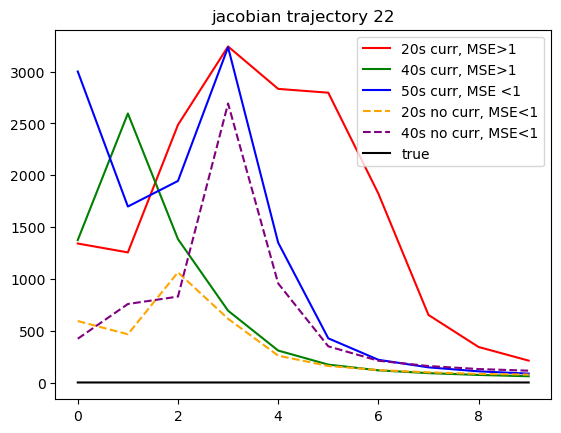

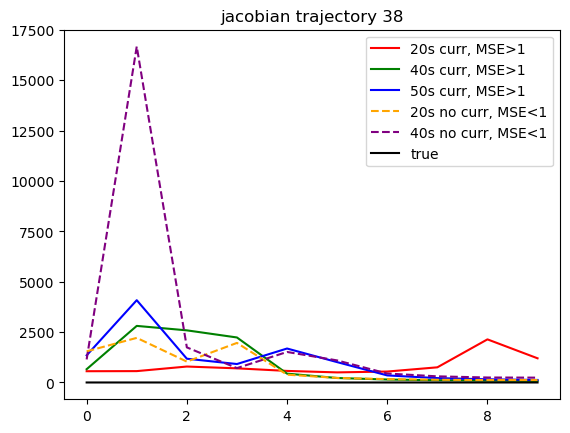

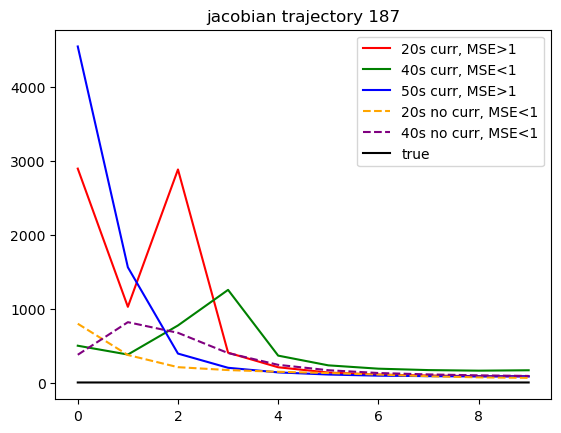

In [281]:
plt.plot(lip_data_outliers_20[0][:10], label='20s curr, MSE>1', color='red')
plt.plot(lip_data_outliers_40[0][:10], label='40s curr, MSE>1', color='green')
plt.plot(lip_data_outliers_50[0][:10], label='50s curr, MSE <1', color='blue')
plt.plot(fa_prime20s_outliers[:10], label='20s no curr, MSE<1', color='orange', linestyle='--')
plt.plot(fa_prime40s_outliers[:10], label='40s no curr, MSE<1', color='purple', linestyle='--')
plt.plot(true_outliers[:10], label='true', color='black')
plt.legend()
plt.title("jacobian trajectory 22")
plt.figure()

plt.plot(lip_data_outliers_20[1][:10], label='20s curr, MSE>1', color='red')
plt.plot(lip_data_outliers_40[1][:10], label='40s curr, MSE>1', color='green')
plt.plot(lip_data_outliers_50[1][:10], label='50s curr, MSE>1', color='blue')
plt.plot(fa_prime20s_outliers_38[:10], label='20s no curr, MSE<1', color='orange', linestyle='--')
plt.plot(fa_prime40s_outliers_38[:10], label='40s no curr, MSE<1', color='purple', linestyle='--')
plt.plot(true_outliers_38[:10], label='true', color='black')
plt.legend()
plt.title("jacobian trajectory 38")
plt.figure()

plt.plot(lip_data_outliers_20[2][:10], label='20s curr, MSE>1', color='red')
plt.plot(lip_data_outliers_40[2][:10], label='40s curr, MSE<1', color='green')
plt.plot(lip_data_outliers_50[2][:10], label='50s curr, MSE>1', color='blue')
plt.plot(fa_prime20s_outliers_187[:10], label='20s no curr, MSE<1', color='orange', linestyle='--')
plt.plot(fa_prime40s_outliers_187[:10], label='40s no curr, MSE<1', color='purple', linestyle='--')
plt.plot(true_outliers_187[:10], label='true', color='black')
plt.legend()
plt.title("jacobian trajectory 187")


# plt.plot(lip_data_outliers_20[2][:10], label='20s curr', color='red')
# plt.plot(lip_data_outliers_40[2][:10], label='40s curr', color='green')
# plt.plot(lip_data_outliers_50[2][:10], label='50s curr', color='blue')
# plt.plot(fa_prime20s_outliers_187[:10], label='20s no curr', color='black', linestyle='--')
# plt.plot(fa_prime40s_outliers_187[:10], label='40s no curr', color='orange', linestyle='--')
# plt.legend()
# plt.title("trajectory 187")
# plt.figure()




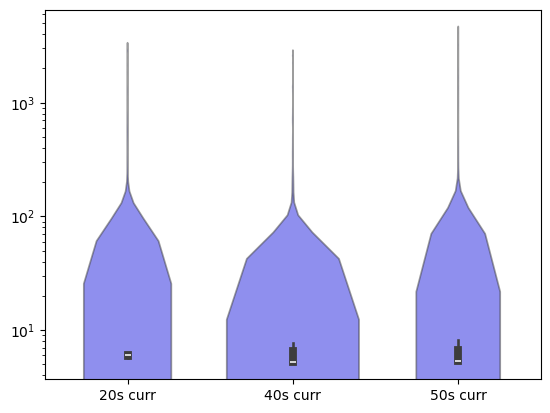

In [234]:
sns.violinplot(df_outliers, color='blue', alpha=0.5)
plt.yscale('log')


### Lip outliers

Text(0.5, 1.0, 'Trajectory 22')

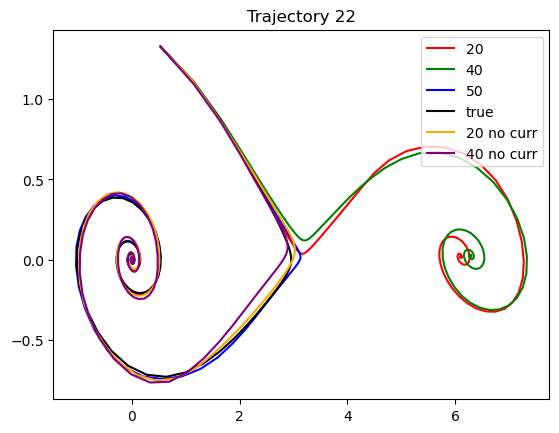

In [280]:
plt.plot(data_aug_none20["y_pred"][outliers_20[0]][0,:], data_aug_none20["y_pred"][outliers_20[0]][1,:], label='20', color='red')
plt.plot(data_aug_none40["y_pred"][outliers_20[0]][0,:], data_aug_none40["y_pred"][outliers_20[0]][1,:], label='40', color='green')
plt.plot(data_aug_none50["y_pred"][outliers_20[0]][0,:], data_aug_none50["y_pred"][outliers_20[0]][1,:], label='50', color='blue')
plt.plot(data_aug_none20["y_true"][outliers_20[0]][0,:], data_aug_none20["y_true"][outliers_20[0]][1,:], label='true', color='black')
plt.plot(data_aug_none_Fa_prime20_l10_tau10_nocurr["y_pred"][outliers_20[0]][0,:], data_aug_none_Fa_prime20_l10_tau10_nocurr["y_pred"][outliers_20[0]][1,:], label='20 no curr', color='orange')
plt.plot(data_aug_none_Fa_prime40_l10_tau10_nocurr["y_pred"][outliers_20[0]][0,:], data_aug_none_Fa_prime40_l10_tau10_nocurr["y_pred"][outliers_20[0]][1,:], label='40 no curr', color='purple')
# plt.scatter(data_aug_none_Fa_prime20_l10_tau10_nocurr["y_pred"][outliers_20[0]][0,2], data_aug_none_Fa_prime20_l10_tau10_nocurr["y_pred"][outliers_20[0]][1,2], color='orange', marker='x', label="max jacobian")
# plt.scatter(data_aug_none_Fa_prime40_l10_tau10_nocurr["y_pred"][outliers_20[0]][0,3], data_aug_none_Fa_prime40_l10_tau10_nocurr["y_pred"][outliers_20[0]][1,3], color='purple', marker='x', label="max jacobian")
plt.legend()
plt.title("Trajectory 22")

Text(0.5, 1.0, 'Trajectory 38')

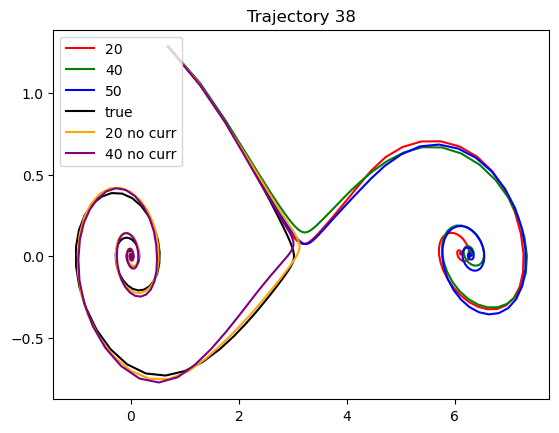

In [282]:
plt.plot(data_aug_none20["y_pred"][outliers_20[1]][0,:], data_aug_none20["y_pred"][outliers_20[1]][1,:], label='20', color='red')
plt.plot(data_aug_none40["y_pred"][outliers_20[1]][0,:], data_aug_none40["y_pred"][outliers_20[1]][1,:], label='40', color='green')
plt.plot(data_aug_none50["y_pred"][outliers_20[1]][0,:], data_aug_none50["y_pred"][outliers_20[1]][1,:], label='50', color='blue')
plt.plot(data_aug_none20["y_true"][outliers_20[1]][0,:], data_aug_none20["y_true"][outliers_20[1]][1,:], label='true', color='black')
plt.plot(data_aug_none_Fa_prime20_l10_tau10_nocurr["y_pred"][outliers_20[1]][0,:], data_aug_none_Fa_prime20_l10_tau10_nocurr["y_pred"][outliers_20[1]][1,:], label='20 no curr', color='orange')
plt.plot(data_aug_none_Fa_prime40_l10_tau10_nocurr["y_pred"][outliers_20[1]][0,:], data_aug_none_Fa_prime40_l10_tau10_nocurr["y_pred"][outliers_20[1]][1,:], label='40 no curr', color='purple')
# plt.scatter(data_aug_none_Fa_prime20_l10_tau10_nocurr["y_pred"][outliers_20[0]][0,2], data_aug_none_Fa_prime20_l10_tau10_nocurr["y_pred"][outliers_20[0]][1,2], color='orange', marker='x', label="max jacobian")
# plt.scatter(data_aug_none_Fa_prime40_l10_tau10_nocurr["y_pred"][outliers_20[0]][0,3], data_aug_none_Fa_prime40_l10_tau10_nocurr["y_pred"][outliers_20[0]][1,3], color='purple', marker='x', label="max jacobian")
plt.legend()
plt.title("Trajectory 38")

Text(0.5, 1.0, 'Trajectory 187')

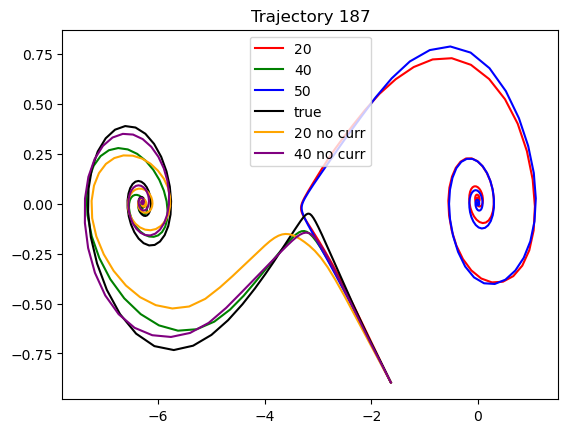

In [283]:
plt.plot(data_aug_none20["y_pred"][outliers_20[2]][0,:], data_aug_none20["y_pred"][outliers_20[2]][1,:], label='20', color='red')
plt.plot(data_aug_none40["y_pred"][outliers_20[2]][0,:], data_aug_none40["y_pred"][outliers_20[2]][1,:], label='40', color='green')
plt.plot(data_aug_none50["y_pred"][outliers_20[2]][0,:], data_aug_none50["y_pred"][outliers_20[2]][1,:], label='50', color='blue')
plt.plot(data_aug_none20["y_true"][outliers_20[2]][0,:], data_aug_none20["y_true"][outliers_20[2]][1,:], label='true', color='black')
plt.plot(data_aug_none_Fa_prime20_l10_tau10_nocurr["y_pred"][outliers_20[2]][0,:], data_aug_none_Fa_prime20_l10_tau10_nocurr["y_pred"][outliers_20[2]][1,:], label='20 no curr', color='orange')
plt.plot(data_aug_none_Fa_prime40_l10_tau10_nocurr["y_pred"][outliers_20[2]][0,:], data_aug_none_Fa_prime40_l10_tau10_nocurr["y_pred"][outliers_20[2]][1,:], label='40 no curr', color='purple')
# plt.scatter(data_aug_none_Fa_prime20_l10_tau10_nocurr["y_pred"][outliers_20[0]][0,2], data_aug_none_Fa_prime20_l10_tau10_nocurr["y_pred"][outliers_20[0]][1,2], color='orange', marker='x', label="max jacobian")
# plt.scatter(data_aug_none_Fa_prime40_l10_tau10_nocurr["y_pred"][outliers_20[0]][0,3], data_aug_none_Fa_prime40_l10_tau10_nocurr["y_pred"][outliers_20[0]][1,3], color='purple', marker='x', label="max jacobian")
plt.legend()
plt.title("Trajectory 187")

Text(0.5, 1.0, 'Trajectory 0')

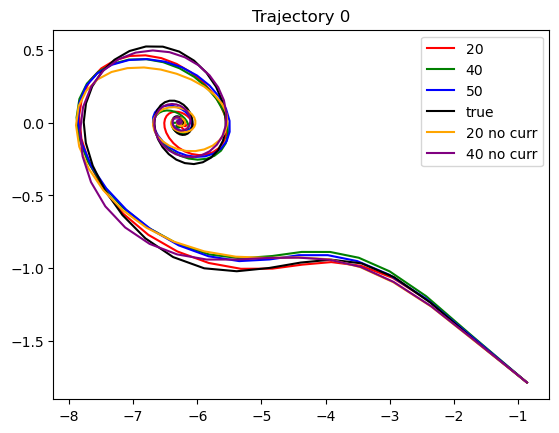

In [284]:
plt.plot(data_aug_none20["y_pred"][0][0,:], data_aug_none20["y_pred"][0][1,:], label='20', color='red')
plt.plot(data_aug_none40["y_pred"][0][0,:], data_aug_none40["y_pred"][0][1,:], label='40', color='green')
plt.plot(data_aug_none50["y_pred"][0][0,:], data_aug_none50["y_pred"][0][1,:], label='50', color='blue')
plt.plot(data_aug_none20["y_true"][0][0,:], data_aug_none20["y_true"][0][1,:], label='true', color='black')
plt.plot(data_aug_none_Fa_prime20_l10_tau10_nocurr["y_pred"][0][0,:], data_aug_none_Fa_prime20_l10_tau10_nocurr["y_pred"][0][1,:], label='20 no curr', color='orange')
plt.plot(data_aug_none_Fa_prime40_l10_tau10_nocurr["y_pred"][0][0,:], data_aug_none_Fa_prime40_l10_tau10_nocurr["y_pred"][0][1,:], label='40 no curr', color='purple')
# plt.scatter(data_aug_none_Fa_prime20_l10_tau10_nocurr["y_pred"][outliers_20[0]][0,2], data_aug_none_Fa_prime20_l10_tau10_nocurr["y_pred"][outliers_20[0]][1,2], color='orange', marker='x', label="max jacobian")
# plt.scatter(data_aug_none_Fa_prime40_l10_tau10_nocurr["y_pred"][outliers_20[0]][0,3], data_aug_none_Fa_prime40_l10_tau10_nocurr["y_pred"][outliers_20[0]][1,3], color='purple', marker='x', label="max jacobian")
plt.legend()
plt.title("Trajectory 0")

In [293]:
def compute_lip_outliers_good(indices, model):
    lip_data_outliers = []
    for i in indices:
        traj = metrics_aug_none20["y_true"][i]
        print(traj.shape)
        lip_traj = []
        for k in range(traj.shape[1]):
            print(k)
            lip_traj.append(np.linalg.norm(jacobian(model.model_aug, traj[:,k])))  
        lip_data_outliers.append(lip_traj)
    return lip_data_outliers

lip_data_outliers_20 = compute_lip_outliers_good(outliers_20, aug_none20)
# lip_data_outliers_40 = compute_lip_outliers_good(outliers_20, aug_none40)
# lip_data_outliers_50 = compute_lip_outliers_good(outliers_20, aug_none50)
# lip_data_outliers_Fa_prime20 = compute_lip_outliers_good(outliers_20, aug_none_Fa_prime20_l10_tau10_nocurr)
# lip_data_outliers_Fa_prime40 = compute_lip_outliers_good(outliers_20, aug_none_Fa_prime40_l10_tau10_nocurr)

(2, 401)
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
2

In [296]:
lip_data_outliers_Fa_prime20 = compute_lip_outliers_good(outliers_20, aug_none_Fa_prime20_l10_tau10_nocurr)

(2, 401)
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
2

In [297]:
def compute_lip_outliers_true(indices):
    lip_data_outliers = []
    for i in indices:
        traj = metrics_aug_none20["y_true"][i]
        print(traj.shape)
        lip_traj = []
        for k in range(traj.shape[1]):
            print(k)
            lip_traj.append(np.linalg.norm(jacobian(F_y, traj[:,k])))  
        lip_data_outliers.append(lip_traj)
    return lip_data_outliers

In [299]:
lip_true = compute_lip_outliers_true(outliers_20)

(2, 401)
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
2

Text(0.5, 1.0, 'jac traj 187')

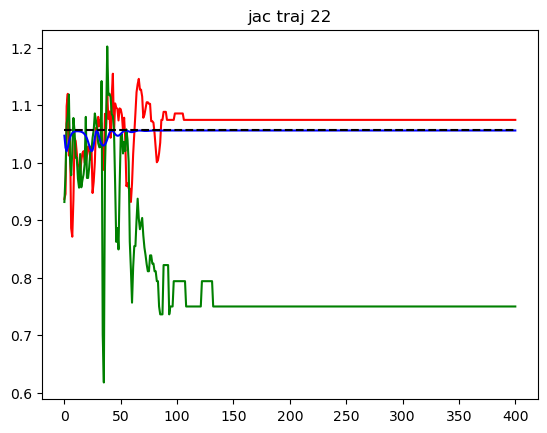

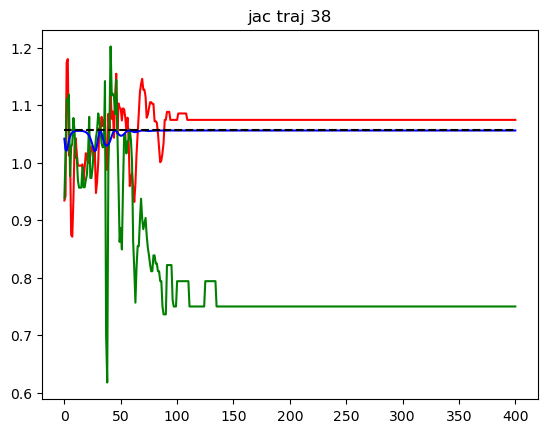

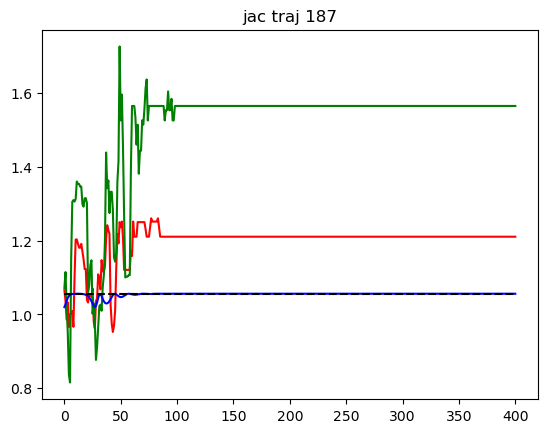

In [303]:
plt.plot(lip_data_outliers_20[0][:], label='20s curr, MSE>1', color='red')
plt.plot(lip_data_outliers_Fa_prime20[0][:], label='40s curr, MSE>1', color='green')
plt.plot(lip_true[0], label='true', color='blue')
plt.hlines(L_true, 0, 400, linestyles='dashed', color='black', label='True Lipschitz constant')
plt.title("jac traj 22")

plt.figure()
plt.plot(lip_data_outliers_20[1][:], label='20s curr, MSE>1', color='red')
plt.plot(lip_data_outliers_Fa_prime20[1][:], label='40s curr, MSE>1', color='green')
plt.plot(lip_true[1], label='true', color='blue')
plt.hlines(L_true, 0, 400, linestyles='dashed', color='black', label='True Lipschitz constant')
plt.title("jac traj 38")

plt.figure()
plt.plot(lip_data_outliers_20[2][:], label='20s curr, MSE>1', color='red')
plt.plot(lip_data_outliers_Fa_prime20[2][:], label='40s curr, MSE>1', color='green')
plt.plot(lip_true[2], label='true', color='blue')
plt.hlines(L_true, 0, 400, linestyles='dashed', color='black', label='True Lipschitz constant')
plt.title("jac traj 187")

## comparison fa prime

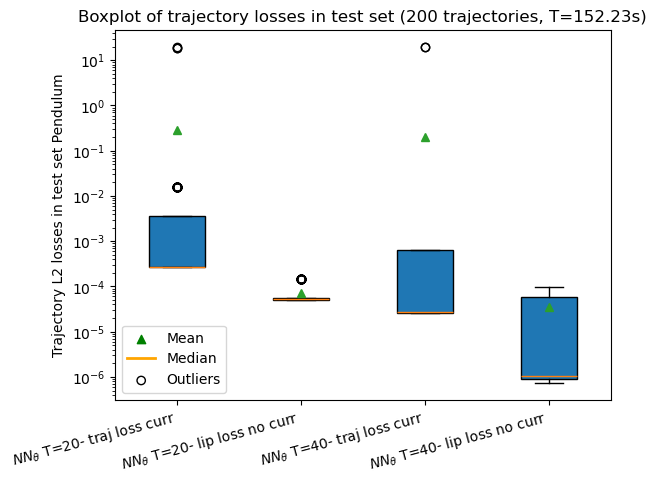

In [132]:
# boxplot meilleur

losses_traj = [
    metrics_aug_none20["L2_dynamic"],
    metrics_aug_none_Fa_prime20_l10_tau10_nocurr["L2_dynamic"],
    metrics_aug_none40["L2_dynamic"],
    metrics_aug_none_Fa_prime40_l10_tau10_nocurr["L2_dynamic"],
]
labels = [
    r'$NN_{\theta}$ T=20- traj loss curr',
    r'$NN_{\theta}$ T=20- lip loss no curr',
    r'$NN_{\theta}$ T=40- traj loss curr',
    r'$NN_{\theta}$ T=40- lip loss no curr']
#colors = ['peachpuff', 'orange', 'tomato']

fig, ax = plt.subplots()
ax.set_ylabel('Trajectory L2 losses in test set Pendulum')
#ax.set_ylim(0.005,0.5)
ax.set_yscale('log')


# orientation en biais
bplot = ax.boxplot(
    losses_traj,
    patch_artist=True,
    showmeans=True
)

ax.set_xticks([1, 2, 3, 4])
ax.set_xticklabels(labels, rotation=15, ha='right')
# dummy legend
mean_legend = plt.scatter([], [], color='green', marker='^', label='Mean')
median_legend = plt.Line2D([0], [0], color='orange', linewidth=2, label='Median')
outlier_legend = plt.scatter([],[], marker= 'o',edgecolors='black', facecolors='none', label='Outliers')

ax.legend(handles=[mean_legend, median_legend, outlier_legend], loc='lower left')
# fill with colors
# for patch, color in zip(bplot['boxes'], colors):
#     patch.set_facecolor(color)
plt.title(f"Boxplot of trajectory losses in test set (200 trajectories, T={mean_T}s)")
plt.show()

In [472]:
metrics_aug_none20_bis = compute_metrics(data_aug_none20, compute_phy=False, eps=0.1)
metrics_aug_none_Fa_prime20_l10_tau10_nocurr_bis = compute_metrics(data_aug_none_Fa_prime20_l10_tau10_nocurr, compute_phy=False, eps=0.1)
metrics_aug_none40_bis = compute_metrics(data_aug_none40, compute_phy=False, eps=0.1)
metrics_aug_none_Fa_prime40_l10_tau10_nocurr_bis = compute_metrics(data_aug_none_Fa_prime40_l10_tau10_nocurr, compute_phy=False, eps=0.1)



In [474]:
metrics_aug_none20_bis["stationary_index"].mean()

105.87

In [503]:
T_mean_bis = metrics_aug_none20_bis["stationary_index"].mean()

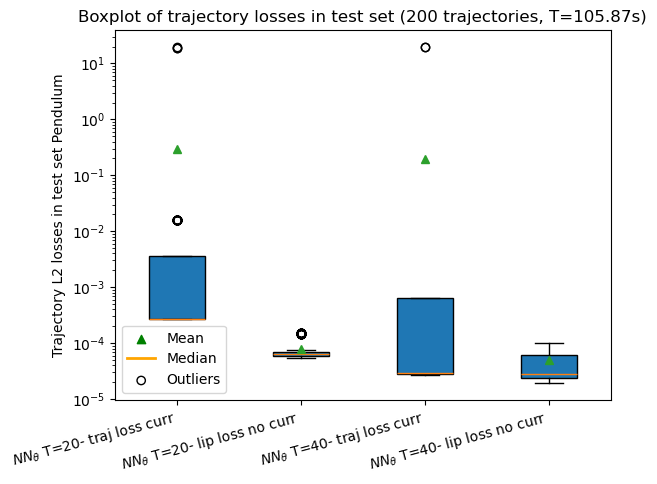

In [504]:
# boxplot meilleur

losses_traj = [
    metrics_aug_none20_bis["L2_dynamic"],
    metrics_aug_none_Fa_prime20_l10_tau10_nocurr_bis["L2_dynamic"],
    metrics_aug_none40_bis["L2_dynamic"],
    metrics_aug_none_Fa_prime40_l10_tau10_nocurr_bis["L2_dynamic"],
]
labels = [
    r'$NN_{\theta}$ T=20- traj loss curr',
    r'$NN_{\theta}$ T=20- lip loss no curr',
    r'$NN_{\theta}$ T=40- traj loss curr',
    r'$NN_{\theta}$ T=40- lip loss no curr']
#colors = ['peachpuff', 'orange', 'tomato']

fig, ax = plt.subplots()
ax.set_ylabel('Trajectory L2 losses in test set Pendulum')
#ax.set_ylim(0.005,0.5)
ax.set_yscale('log')


# orientation en biais
bplot = ax.boxplot(
    losses_traj,
    patch_artist=True,
    showmeans=True
)

ax.set_xticks([1, 2, 3, 4])
ax.set_xticklabels(labels, rotation=15, ha='right')
# dummy legend
mean_legend = plt.scatter([], [], color='green', marker='^', label='Mean')
median_legend = plt.Line2D([0], [0], color='orange', linewidth=2, label='Median')
outlier_legend = plt.scatter([],[], marker= 'o',edgecolors='black', facecolors='none', label='Outliers')

ax.legend(handles=[mean_legend, median_legend, outlier_legend], loc='lower left')
# fill with colors
# for patch, color in zip(bplot['boxes'], colors):
#     patch.set_facecolor(color)
plt.title(f"Boxplot of trajectory losses in test set (200 trajectories, T={T_mean_bis}s)")
plt.show()

In [141]:
def save_data_traj(data, path):
    data.to_csv(path, index=False)

def load_data_traj(path):
    data = pd.read_csv(path)
    return data

In [143]:
save_data_traj(data_aug_none5, "/Users/mayajanvier/jax-phynity/data/lipschitz_curriculum/none_aug_5_1_9823b25a/data_6.339e-04.csv")
save_data_traj(data_aug_none10, "/Users/mayajanvier/jax-phynity/data/lipschitz_curriculum/none_aug_10_5_atx793p0/data_3.829e-03.csv")
save_data_traj(data_aug_none15, "/Users/mayajanvier/jax-phynity/data/lipschitz_curriculum/none_aug_15_18_4xaco8ba/data_1.257e-02.csv")
save_data_traj(data_aug_none20, "/Users/mayajanvier/jax-phynity/data/lipschitz_curriculum/none_aug_20_9_zbgnkgq4/data_6.752e-03.csv")
save_data_traj(data_aug_none25, "/Users/mayajanvier/jax-phynity/data/lipschitz_curriculum/none_aug_25_22_egopf2x9/data_8.102e-03.csv")
save_data_traj(data_aug_none30, "/Users/mayajanvier/jax-phynity/data/lipschitz_curriculum/none_aug_30_26_d6w9bgr7/data_3.157e-03.csv")
save_data_traj(data_aug_none35, "/Users/mayajanvier/jax-phynity/data/lipschitz_curriculum/none_aug_35_30_cqsxyvkz/data_1.410e-03.csv")
save_data_traj(data_aug_none40, "/Users/mayajanvier/jax-phynity/data/lipschitz_curriculum/none_aug_40_14_ydq9q5k5/data_2.862e-03.csv")
save_data_traj(data_aug_none50, "/Users/mayajanvier/jax-phynity/data/lipschitz_curriculum/none_aug_50_40_ftfbayku/data_1.702e-03.csv")

# Fa prime
save_data_traj(data_aug_none_Fa_prime20_l10_tau10_nocurr, "/Users/mayajanvier/jax-phynity/data/lipschitz_init/none_Fa_prime_aug_20_21_2lnfi7xs/data_5.633e-03.csv")
save_data_traj(data_aug_none_Fa_prime40_l10_tau10_nocurr, "/Users/mayajanvier/jax-phynity/data/lipschitz_init/none_Fa_prime_aug_40_33_t7uthp7u/data_2.493e-03.csv")

In [772]:
data_aug_none10.to_pickle("/Users/mayajanvier/jax-phynity/data/lipschitz_curriculum/none_aug_10_5_atx793p0/data_3.829e-03.pkl")
data_aug_none20.to_pickle("/Users/mayajanvier/jax-phynity/data/lipschitz_curriculum/none_aug_20_9_zbgnkgq4/data_6.752e-03.pkl")
data_aug_none25.to_pickle("/Users/mayajanvier/jax-phynity/data/lipschitz_curriculum/none_aug_25_22_egopf2x9/data_8.102e-03.pkl")
data_aug_none30.to_pickle("/Users/mayajanvier/jax-phynity/data/lipschitz_curriculum/none_aug_30_26_d6w9bgr7/data_3.157e-03.pkl")
data_aug_none35.to_pickle("/Users/mayajanvier/jax-phynity/data/lipschitz_curriculum/none_aug_35_30_cqsxyvkz/data_1.410e-03.pkl")
data_aug_none40.to_pickle("/Users/mayajanvier/jax-phynity/data/lipschitz_curriculum/none_aug_40_14_ydq9q5k5/data_2.862e-03.pkl")
data_aug_none50.to_pickle("/Users/mayajanvier/jax-phynity/data/lipschitz_curriculum/none_aug_50_40_ftfbayku/data_1.702e-03.pkl")

In [773]:
data_aug_none15.to_pickle("/Users/mayajanvier/jax-phynity/data/lipschitz_curriculum/none_aug_15_18_4xaco8ba/data_1.257e-02.pkl")

In [774]:
data_aug_none_Fa_prime20_l10_tau10_nocurr.to_pickle("/Users/mayajanvier/jax-phynity/data/lipschitz_init/none_Fa_prime_aug_20_21_2lnfi7xs/data_5.633e-03.pkl")
data_aug_none_Fa_prime40_l10_tau10_nocurr.to_pickle("/Users/mayajanvier/jax-phynity/data/lipschitz_init/none_Fa_prime_aug_40_33_t7uthp7u/data_2.493e-03.pkl")

## effet de ma loss

In [690]:
# /Users/mayajanvier/jax-phynity/data/lipschitz_curriculum/none_Fa_prime_aug_20_32_zixysqbb/model_1.133e-01.eqx
exp_name = 'none_Fa_prime_aug_20_32_zixysqbb'
data_path = 'data/lipschitz_curriculum'
model_name = "model_1.133e-01.eqx"
model_phy_option = 'none_Fa_prime'
model_aug_option = True
dataset_name = 'pendulum'
integration_method = 'RK4'
duration = 20
dt_num = 0.5
aug_none_Fa_prime20_l1000_tau0_curr = load_pendulum(model_name,exp_name, data_path, model_phy_option, model_aug_option, dataset_name, integration_method, dt_num=dt_num, duration=duration)

data/lipschitz_curriculum/none_Fa_prime_aug_20_32_zixysqbb/model_1.133e-01.eqx
0.5 1


In [693]:
F_aug_none_Fa_prime20_l1000_tau0_curr = aug_none_Fa_prime20_l1000_tau0_curr.derivative_estimator
data_aug_none_Fa_prime20_l1000_tau0_curr = compute_trajectories(F_aug_none_Fa_prime20_l1000_tau0_curr, y0s, dt_truth=0.5, t1=200)

KeyboardInterrupt: 

In [ ]:
# /Users/mayajanvier/jax-phynity/data/lipschitz_curriculum/none_Fa_prime_aug_20_48_hop0f1ls/model_3.056e-02.eqx 
# l=10000

# /Users/mayajanvier/jax-phynity/data/lipschitz_curriculum/none_Fa_prime_aug_20_49_2pb2wz7e/model_8.495e-02.eqx
# supervision fa_prime

In [701]:
# /Users/mayajanvier/jax-phynity/data/lipschitz_curriculum/none_Fa_prime_aug_20_50_59rc5arp/model_3.789e-03.eqx
model_name = "model_3.789e-03.eqx"
exp_name = 'none_Fa_prime_aug_20_50_59rc5arp'
data_path = 'data/lipschitz_curriculum'
model_phy_option = 'none_Fa_prime'
model_aug_option = True
dataset_name = 'pendulum'
integration_method = 'RK4'
dt_num = 0.5
duration = 20
aug_none_Fa_prime20_l100_sup_curr = load_pendulum(model_name,exp_name, data_path, model_phy_option, model_aug_option, dataset_name, integration_method, dt_num=dt_num, duration=duration)

data/lipschitz_curriculum/none_Fa_prime_aug_20_50_59rc5arp/model_3.789e-03.eqx
0.5 1


In [730]:
# /Users/mayajanvier/jax-phynity/data/lipschitz_curriculum/none_Fa_prime_aug_10_51_roozf1h9/model_2.263e-03.eqx
model_name = "model_2.263e-03.eqx"
exp_name = 'none_Fa_prime_aug_10_51_roozf1h9'
data_path = 'data/lipschitz_curriculum'
model_phy_option = 'none_Fa_prime'
model_aug_option = True
dataset_name = 'pendulum'
integration_method = 'RK4'
dt_num = 0.5
duration = 10
aug_none_Fa_prime10_l100_sup_curr = load_pendulum(model_name,exp_name, data_path, model_phy_option, model_aug_option, dataset_name, integration_method, dt_num=dt_num, duration=duration)

data/lipschitz_curriculum/none_Fa_prime_aug_10_51_roozf1h9/model_2.263e-03.eqx
0.5 1


In [729]:
# /Users/mayajanvier/jax-phynity/data/lipschitz_curriculum/none_Fa_prime_aug_30_52_erlyimte/model_4.451e-03.eqx
model_name = "model_4.451e-03.eqx"
exp_name = 'none_Fa_prime_aug_30_52_erlyimte'
data_path = 'data/lipschitz_curriculum'
model_phy_option = 'none_Fa_prime'
model_aug_option = True
dataset_name = 'pendulum'
integration_method = 'RK4'
dt_num = 0.5
duration = 30
aug_none_Fa_prime30_l100_sup_curr = load_pendulum(model_name,exp_name, data_path, model_phy_option, model_aug_option, dataset_name, integration_method, dt_num=dt_num, duration=duration)

data/lipschitz_curriculum/none_Fa_prime_aug_30_52_erlyimte/model_4.451e-03.eqx
0.5 1


In [731]:
# /Users/mayajanvier/jax-phynity/data/lipschitz_curriculum/none_Fa_prime_aug_40_57_ngisx048/model_2.900e-03.eqx
model_name = "model_2.900e-03.eqx"
exp_name = 'none_Fa_prime_aug_40_57_ngisx048'
data_path = 'data/lipschitz_curriculum'
model_phy_option = 'none_Fa_prime'
model_aug_option = True
dataset_name = 'pendulum'
integration_method = 'RK4'
dt_num = 0.5
duration = 40
aug_none_Fa_prime40_l100_sup_curr = load_pendulum(model_name,exp_name, data_path, model_phy_option, model_aug_option, dataset_name, integration_method, dt_num=dt_num, duration=duration)

data/lipschitz_curriculum/none_Fa_prime_aug_40_57_ngisx048/model_2.900e-03.eqx
0.5 1


In [732]:
F_aug_none_Fa_prime10_l100_sup_curr = aug_none_Fa_prime10_l100_sup_curr.derivative_estimator
F_aug_none_Fa_prime30_l100_sup_curr = aug_none_Fa_prime30_l100_sup_curr.derivative_estimator
F_aug_none_Fa_prime40_l100_sup_curr = aug_none_Fa_prime40_l100_sup_curr.derivative_estimator

In [733]:
data_aug_none_Fa_prime10_l100_sup_curr = compute_trajectories(F_aug_none_Fa_prime10_l100_sup_curr, y0s, dt_truth=0.5, t1=200)

In [736]:
data_aug_none_Fa_prime30_l100_sup_curr = compute_trajectories(F_aug_none_Fa_prime30_l100_sup_curr, y0s, dt_truth=0.5, t1=200)

In [739]:
data_aug_none_Fa_prime40_l100_sup_curr = compute_trajectories(F_aug_none_Fa_prime40_l100_sup_curr, y0s, dt_truth=0.5, t1=200)

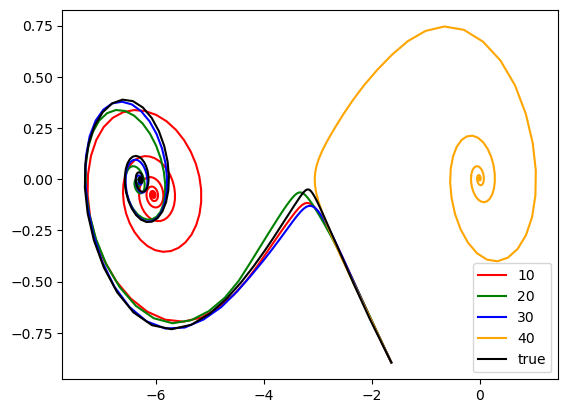

In [742]:
k=187
plt.plot(data_aug_none_Fa_prime10_l100_sup_curr["y_pred"][k][0,:], data_aug_none_Fa_prime10_l100_sup_curr["y_pred"][k][1,:], label='10', color='red')
plt.plot(data_aug_none_Fa_prime20_l100_sup_curr["y_pred"][k][0,:], data_aug_none_Fa_prime20_l100_sup_curr["y_pred"][k][1,:], label='20', color='green')
plt.plot(data_aug_none_Fa_prime30_l100_sup_curr["y_pred"][k][0,:], data_aug_none_Fa_prime30_l100_sup_curr["y_pred"][k][1,:], label='30', color='blue')
plt.plot(data_aug_none_Fa_prime40_l100_sup_curr["y_pred"][k][0,:], data_aug_none_Fa_prime40_l100_sup_curr["y_pred"][k][1,:], label='40', color='orange')
plt.plot(data_aug_none_Fa_prime20_l100_sup_curr["y_true"][k][0,:], data_aug_none_Fa_prime20_l100_sup_curr["y_true"][k][1,:], label='true', color='black')
plt.legend()

In [703]:
F_aug_none_Fa_prime20_l100_sup_curr = aug_none_Fa_prime20_l100_sup_curr.derivative_estimator
data_aug_none_Fa_prime20_l100_sup_curr = compute_trajectories(F_aug_none_Fa_prime20_l100_sup_curr, y0s, dt_truth=0.5, t1=200)

In [724]:
save_data_traj(data_aug_none_Fa_prime20_l100_sup_curr, "/Users/mayajanvier/jax-phynity/data/lipschitz_curriculum/none_Fa_prime_aug_20_50_59rc5arp/data_3.789e-03.csv")

In [743]:
#save_data_traj(data_aug_none_Fa_prime10_l100_sup_curr, "/Users/mayajanvier/jax-phynity/data/lipschitz_curriculum/none_Fa_prime_aug_10_51_roozf1h9/data_2.263e-03.csv")
#save_data_traj(data_aug_none_Fa_prime30_l100_sup_curr, "/Users/mayajanvier/jax-phynity/data/lipschitz_curriculum/none_Fa_prime_aug_30_52_erlyimte/data_4.451e-03.csv")
save_data_traj(data_aug_none_Fa_prime40_l100_sup_curr, "/Users/mayajanvier/jax-phynity/data/lipschitz_curriculum/none_Fa_prime_aug_40_57_ngisx048/data_2.900e-03.csv")

In [776]:
data_aug_none_Fa_prime20_l100_sup_curr.to_pickle("/Users/mayajanvier/jax-phynity/data/lipschitz_curriculum/none_Fa_prime_aug_20_50_59rc5arp/data_3.789e-03.pkl")
data_aug_none_Fa_prime10_l100_sup_curr.to_pickle("/Users/mayajanvier/jax-phynity/data/lipschitz_curriculum/none_Fa_prime_aug_10_51_roozf1h9/data_2.263e-03.pkl")
data_aug_none_Fa_prime30_l100_sup_curr.to_pickle("/Users/mayajanvier/jax-phynity/data/lipschitz_curriculum/none_Fa_prime_aug_30_52_erlyimte/data_4.451e-03.pkl")
data_aug_none_Fa_prime40_l100_sup_curr.to_pickle("/Users/mayajanvier/jax-phynity/data/lipschitz_curriculum/none_Fa_prime_aug_40_57_ngisx048/data_2.900e-03.pkl")

In [744]:
metrics_aug_none_Fa_prime20_l100_sup_curr = compute_metrics(data_aug_none_Fa_prime20_l100_sup_curr, compute_phy=False, eps=0.01)
metrics_aug_none_Fa_prime10_l100_sup_curr = compute_metrics(data_aug_none_Fa_prime10_l100_sup_curr, compute_phy=False, eps=0.01)
metrics_aug_none_Fa_prime30_l100_sup_curr = compute_metrics(data_aug_none_Fa_prime30_l100_sup_curr, compute_phy=False, eps=0.01)
metrics_aug_none_Fa_prime40_l100_sup_curr = compute_metrics(data_aug_none_Fa_prime40_l100_sup_curr, compute_phy=False, eps=0.01)

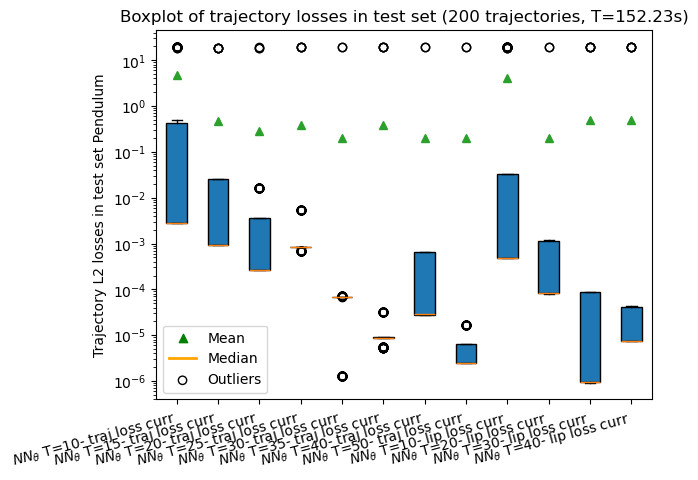

In [745]:
# boxplot meilleur

losses_traj = [
    metrics_aug_none10["L2_dynamic"],
    metrics_aug_none15["L2_dynamic"],
    metrics_aug_none20["L2_dynamic"],
    metrics_aug_none25["L2_dynamic"],
    metrics_aug_none30["L2_dynamic"],
    metrics_aug_none35["L2_dynamic"],
    metrics_aug_none40["L2_dynamic"],
    metrics_aug_none50["L2_dynamic"],
    metrics_aug_none_Fa_prime10_l100_sup_curr["L2_dynamic"],
    metrics_aug_none_Fa_prime20_l100_sup_curr["L2_dynamic"],
    metrics_aug_none_Fa_prime30_l100_sup_curr["L2_dynamic"],
    metrics_aug_none_Fa_prime40_l100_sup_curr["L2_dynamic"]


]
labels = [
          r'$NN_{\theta}$ T=10- traj loss curr',
          r'$NN_{\theta}$ T=15- traj loss curr',
          r'$NN_{\theta}$ T=20- traj loss curr',
          r'$NN_{\theta}$ T=25- traj loss curr',
          r'$NN_{\theta}$ T=30- traj loss curr',
          r'$NN_{\theta}$ T=35- traj loss curr',
          r'$NN_{\theta}$ T=40- traj loss curr',
          r'$NN_{\theta}$ T=50- traj loss curr',
          r'$NN_{\theta}$ T=10- lip loss curr',
          r'$NN_{\theta}$ T=20- lip loss curr',
          r'$NN_{\theta}$ T=30- lip loss curr',
          r'$NN_{\theta}$ T=40- lip loss curr']
#colors = ['peachpuff', 'orange', 'tomato']

fig, ax = plt.subplots()
ax.set_ylabel('Trajectory L2 losses in test set Pendulum')
#ax.set_ylim(0.005,0.5)
ax.set_yscale('log')


# orientation en biais
bplot = ax.boxplot(
    losses_traj,
    patch_artist=True,
    showmeans=True
)

ax.set_xticks([1, 2, 3, 4,5,6,7,8,9,10,11,12])
ax.set_xticklabels(labels, rotation=15, ha='right')
# dummy legend
mean_legend = plt.scatter([], [], color='green', marker='^', label='Mean')
median_legend = plt.Line2D([0], [0], color='orange', linewidth=2, label='Median')
outlier_legend = plt.scatter([],[], marker= 'o',edgecolors='black', facecolors='none', label='Outliers')

ax.legend(handles=[mean_legend, median_legend, outlier_legend], loc='lower left')
# fill with colors
# for patch, color in zip(bplot['boxes'], colors):
#     patch.set_facecolor(color)
plt.title(f"Boxplot of trajectory losses in test set (200 trajectories, T={mean_T}s)")
plt.show()

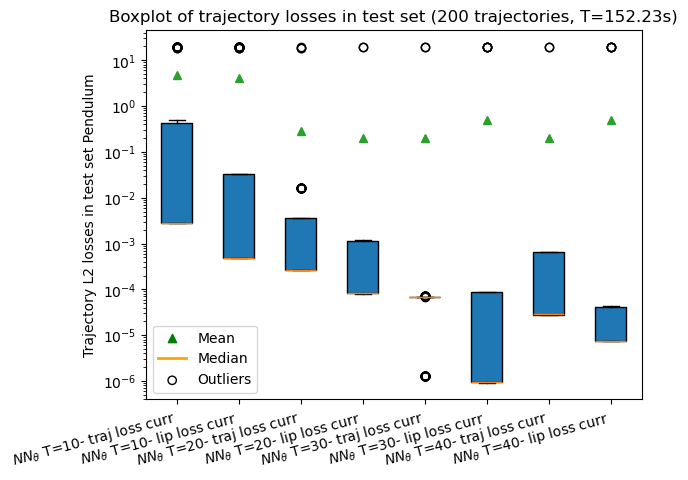

In [750]:
# boxplot meilleur

losses_traj = [
    metrics_aug_none10["L2_dynamic"],
    metrics_aug_none_Fa_prime10_l100_sup_curr["L2_dynamic"],
    #metrics_aug_none15["L2_dynamic"],
    metrics_aug_none20["L2_dynamic"],
    metrics_aug_none_Fa_prime20_l100_sup_curr["L2_dynamic"],
    #metrics_aug_none25["L2_dynamic"],
    metrics_aug_none30["L2_dynamic"],
    metrics_aug_none_Fa_prime30_l100_sup_curr["L2_dynamic"],
    #metrics_aug_none35["L2_dynamic"],
    metrics_aug_none40["L2_dynamic"],
    metrics_aug_none_Fa_prime40_l100_sup_curr["L2_dynamic"]
    #metrics_aug_none50["L2_dynamic"],

]

labels = [
          r'$NN_{\theta}$ T=10- traj loss curr',
          r'$NN_{\theta}$ T=10- lip loss curr',
          #r'$NN_{\theta}$ T=15- traj loss curr',
          r'$NN_{\theta}$ T=20- traj loss curr',
          r'$NN_{\theta}$ T=20- lip loss curr',
          #r'$NN_{\theta}$ T=25- traj loss curr',
          r'$NN_{\theta}$ T=30- traj loss curr',
          r'$NN_{\theta}$ T=30- lip loss curr',
          #r'$NN_{\theta}$ T=35- traj loss curr',
          r'$NN_{\theta}$ T=40- traj loss curr',
          r'$NN_{\theta}$ T=40- lip loss curr']
          #r'$NN_{\theta}$ T=50- traj loss curr',
          
          
          
#colors = ['peachpuff', 'orange', 'tomato']

fig, ax = plt.subplots()
ax.set_ylabel('Trajectory L2 losses in test set Pendulum')
#ax.set_ylim(0.005,0.5)
ax.set_yscale('log')


# orientation en biais
bplot = ax.boxplot(
    losses_traj,
    patch_artist=True,
    showmeans=True
)

ax.set_xticks([1, 2, 3, 4,5,6,7,8])
ax.set_xticklabels(labels, rotation=15, ha='right')
# dummy legend
mean_legend = plt.scatter([], [], color='green', marker='^', label='Mean')
median_legend = plt.Line2D([0], [0], color='orange', linewidth=2, label='Median')
outlier_legend = plt.scatter([],[], marker= 'o',edgecolors='black', facecolors='none', label='Outliers')

ax.legend(handles=[mean_legend, median_legend, outlier_legend], loc='lower left')
# fill with colors
# for patch, color in zip(bplot['boxes'], colors):
#     patch.set_facecolor(color)
plt.title(f"Boxplot of trajectory losses in test set (200 trajectories, T={mean_T}s)")
plt.show()

In [746]:
fa_primes_aug_none20_l100_sup_curr = compute_loss_Fa_prime(aug_none_Fa_prime20_l100_sup_curr)
fa_primes_aug_none20_l100_sup_curr_predict = compute_loss_Fa_prime_true_predict(metrics_aug_none_Fa_prime20_l100_sup_curr)

In [751]:
fa_primes_aug_none10_l100_sup_curr = compute_loss_Fa_prime(aug_none_Fa_prime10_l100_sup_curr)
fa_primes_aug_none10_l100_sup_curr_predict = compute_loss_Fa_prime_true_predict(metrics_aug_none_Fa_prime10_l100_sup_curr)
fa_primes_aug_none30_l100_sup_curr = compute_loss_Fa_prime(aug_none_Fa_prime30_l100_sup_curr)
fa_primes_aug_none30_l100_sup_curr_predict = compute_loss_Fa_prime_true_predict(metrics_aug_none_Fa_prime30_l100_sup_curr)
fa_primes_aug_none40_l100_sup_curr = compute_loss_Fa_prime(aug_none_Fa_prime40_l100_sup_curr)
fa_primes_aug_none40_l100_sup_curr_predict = compute_loss_Fa_prime_true_predict(metrics_aug_none_Fa_prime40_l100_sup_curr)

In [752]:
df_fa_prime_lip_curr = pd.DataFrame({
    "10s curr": fa_primes_aug_none10_l100_sup_curr.mean(axis=2)[:,:80].flatten(),
    "20s curr": fa_primes_aug_none20_l100_sup_curr.mean(axis=2)[:,:80].flatten(),
    "30s curr": fa_primes_aug_none20_l100_sup_curr.mean(axis=2)[:,:80].flatten(),
    "40s curr": fa_primes_aug_none40_l100_sup_curr.mean(axis=2)[:,:80].flatten(),

})

df_fa_prime_lip_curr_predict = pd.DataFrame({
    "10s curr": fa_primes_aug_none10_l100_sup_curr_predict.mean(axis=2)[:,:80].flatten(),
    "20s curr": fa_primes_aug_none20_l100_sup_curr_predict.mean(axis=2)[:,:80].flatten(),
    "30s curr": fa_primes_aug_none30_l100_sup_curr_predict.mean(axis=2)[:,:80].flatten(),
    "40s curr": fa_primes_aug_none40_l100_sup_curr_predict.mean(axis=2)[:,:80].flatten(),
})

In [753]:
diff_fa_primes_lip = pd.DataFrame({
    "10s":np.abs(fa_primes_aug_none10_l100_sup_curr.mean(axis=2)[:,:80].flatten()-fa_primes_true[:,:80,:].mean(axis=2).flatten()),
    "20s":np.abs(fa_primes_aug_none20_l100_sup_curr.mean(axis=2)[:,:80].flatten()-fa_primes_true[:,:80,:].mean(axis=2).flatten()),
    "30s":np.abs(fa_primes_aug_none30_l100_sup_curr.mean(axis=2)[:,:80].flatten()-fa_primes_true[:,:80,:].mean(axis=2).flatten()),
    "40s":np.abs(fa_primes_aug_none40_l100_sup_curr.mean(axis=2)[:,:80].flatten()-fa_primes_true[:,:80,:].mean(axis=2).flatten()),
})

diff_fa_primes_lip_predict = pd.DataFrame({
    "10s":np.abs(fa_primes_aug_none10_l100_sup_curr_predict.mean(axis=2)[:,:80].flatten()-fa_primes_true[:,:80,:].mean(axis=2).flatten()),
    "20s":np.abs(fa_primes_aug_none20_l100_sup_curr_predict.mean(axis=2)[:,:80].flatten()-fa_primes_true[:,:80,:].mean(axis=2).flatten()),
    "30s":np.abs(fa_primes_aug_none30_l100_sup_curr_predict.mean(axis=2)[:,:80].flatten()-fa_primes_true[:,:80,:].mean(axis=2).flatten()),
    "40s":np.abs(fa_primes_aug_none40_l100_sup_curr_predict.mean(axis=2)[:,:80].flatten()-fa_primes_true[:,:80,:].mean(axis=2).flatten()),
})

In [717]:
lip_data_aug_none_lip_l100 = compute_jacobian_test(aug_none_Fa_prime20_l100_sup_curr)

(2025, 2) (2,)


In [765]:
#lip_data_aug_none10_lip_l100 = compute_jacobian_test(aug_none_Fa_prime10_l100_sup_curr)
#lip_data_aug_none30_lip_l100 = compute_jacobian_test(aug_none_Fa_prime30_l100_sup_curr)
lip_data_aug_none40_lip_l100 = compute_jacobian_test(aug_none_Fa_prime40_l100_sup_curr)

(2025, 2) (2,)


In [766]:
df_lip_l100 = pd.DataFrame({
    "10s": lip_data_aug_none10_lip_l100,
    "20s": lip_data_aug_none_lip_l100,
    "30s": lip_data_aug_none30_lip_l100,
    "40s": lip_data_aug_none40_lip_l100,
})

In [767]:
save_data_traj(df_lip_l100, "/Users/mayajanvier/jax-phynity/data/lipschitz_curriculum/lipschitz_curriculum_l100.csv")

In [768]:
df_lip_l100["true"] = df_true
df_L_diff_lip_l100 = df_lip_l100.apply(lambda x: np.abs(x- x["true"]), axis=1)


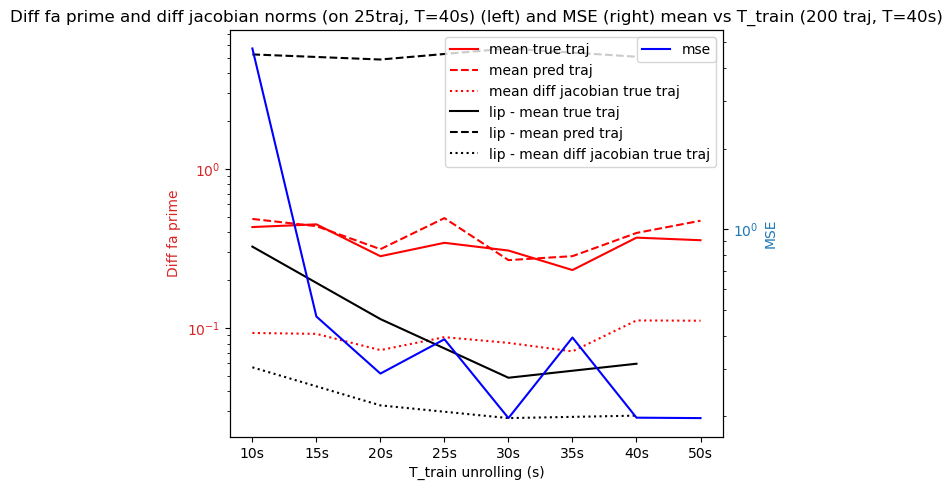

In [771]:
fig, ax1 = plt.subplots()

color = 'tab:red'
ax1.set_xlabel('T_train unrolling (s)')
ax1.set_ylabel('Diff fa prime', color=color)
ax1.plot(diff_fa_primes.mean(), label="mean true traj", color="red")
ax1.plot(diff_fa_prime_predict.mean(), label="mean pred traj", color="red", linestyle="--")
ax1.plot(df_L_diff.mean()[1:-1], label="mean diff jacobian true traj", color="red", linestyle=":")
ax1.plot(diff_fa_primes_lip.mean(), color='black', label='lip - mean true traj')
ax1.plot(diff_fa_primes_lip_predict.mean(), linestyle='dashed', color='black', label='lip - mean pred traj')
ax1.plot(df_L_diff_lip_l100.mean()[:-1], linestyle=":", color="black", label='lip - mean diff jacobian true traj')
#ax1.hlines(df_L_diff_lip_l100.mean(),0,7, linestyles=':', color='black', label='lip - mean diff jacobian true traj')

#ax1.plot(diff_fa_primes.median(), label="median", color="red", linestyle="--")
ax1.set_yscale("log")
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  # instantiate a second Axes that shares the same x-axis

color = 'tab:blue'
ax2.set_ylabel("MSE", color=color)  # we already handled the x-label with ax1
ax2.plot(mse_df.mean(), label="mse", color="blue")

#ax2.plot(mse_df.median(), label="median", color="blue", linestyle="--")
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_yscale("log")

ax2.legend()
ax1.legend()
fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.title("Diff fa prime and diff jacobian norms (on 25traj, T=40s) (left) and MSE (right) mean vs T_train (200 traj, T=40s)")
plt.show()

# out y0

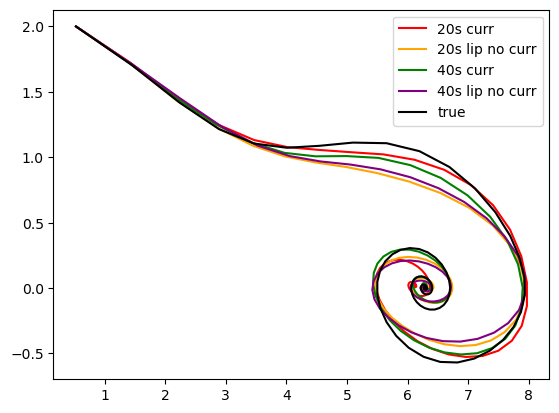

In [465]:
def F(y,t):
    return jnp.array([y[1], -((2*jnp.pi/12)**2) * jnp.sin(y[0]) - 0.2*y[1]])
y0 = jnp.array([0.528,2]) 
dt=0.5
t1=200
traj_20_curr = RK_solver_fixed(F_aug_none20,y0,dt, int((t1 - t0) / dt),RK_tableaux["RK4"])[0]
traj_20_fa_prime_lip =  RK_solver_fixed(F_aug_none_Fa_prime20_l10_tau10_nocurr,y0,dt, int((t1 - t0) / dt),RK_tableaux["RK4"])[0]
traj_40_curr = RK_solver_fixed(F_aug_none40,y0,dt, int((t1 - t0) / dt),RK_tableaux["RK4"])[0]
traj_40_fa_prime_lip = RK_solver_fixed(F_aug_none_Fa_prime40_l10_tau10_nocurr,y0,dt, int((t1 - t0) / dt),RK_tableaux["RK4"])[0]
true_traj = RK_solver_fixed(F, y0,dt,int((t1 - t0) / dt),RK_tableaux["RK4"])[0]
plt.plot(traj_20_curr[0,:], traj_20_curr[1,:], label='20s curr', color='red')
plt.plot(traj_20_fa_prime_lip[0,:], traj_20_fa_prime_lip[1,:], label='20s lip no curr', color='orange')
plt.plot(traj_40_curr[0,:], traj_40_curr[1,:], label='40s curr', color='green')
plt.plot(traj_40_fa_prime_lip[0,:], traj_40_fa_prime_lip[1,:], label='40s lip no curr', color='purple')
plt.plot(true_traj[0,:], true_traj[1,:], label='true', color='black')
plt.legend()

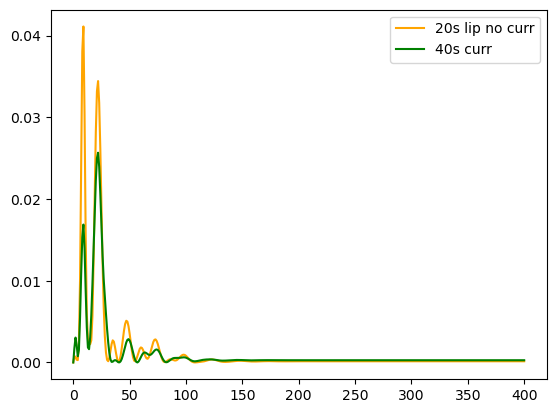

In [471]:
#plt.plot(np.mean((traj_20_curr-true_traj)**2, axis=0), label='20s curr', color='red')
plt.plot(np.mean((traj_20_fa_prime_lip-true_traj)**2, axis=0), label='20s lip no curr', color='orange')
plt.plot(np.mean((traj_40_curr-true_traj)**2, axis=0), label='40s curr', color='green')
#plt.plot(np.mean((traj_40_fa_prime_lip-true_traj)**2, axis=0), label='40s lip no curr', color='purple')
plt.legend()